# Pathway Governance Scenario-Based Evaluation

**Final executable protocol, version 6.2.0**

This notebook evaluates the internal procedural logic of pathway governance across licensing, social assistance and procurement. It is intentionally bounded. The evaluation covers:

1. **60 governance-gate cases** comprising six positive-progression cases, 33 single-condition cases, six compound-condition cases, 12 paired-adversarial cases and three domain-specific cases;
2. **six matched paired checks**, consisting of three Generative AI-confidence pairs and three accountability-record pairs;
3. **17 pre-specified cross-domain checks** examining common progression logic and domain-sensitive institutional routing;
4. Generative AI role-boundary logic, not model quality;
5. accountability-record requirements and their limits, not operational ledger performance;
6. **12 matched infrastructure-selection scenarios** spanning secure logging, conditionally justified blockchain-supported recording and further institutional information;
7. **six infrastructure-selection sensitivity checks**, **nine faulty governance-gate variants** and **four faulty infrastructure-selection variants**; and
8. claim traceability from evaluated governance requirements to the smart-government capacity mapping.

The evaluation supports internal procedural conformance and sensitivity testing within the specified logic. It does **not** establish field effectiveness, legal compliance, administrative fairness, achieved smart-government capacities, Generative AI accuracy, blockchain performance, implementation readiness or external validity.


## 1. Environment, deterministic execution and output package

The evaluation uses no randomness. Scenario inputs and expected outputs are written and hashed before observed-output generation. The evaluator does not read the expected-output tables.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import inspect
import json
import platform
import shutil
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

NOTEBOOK_VERSION = "6.2.0"
SPECIFICATION_VERSION = "6.2.0"
RANDOMNESS_USED = False

OUTPUT_ROOT = Path("pathway_governance_evaluation_v6_2_package")
if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)

for directory in [
    "specification", "provenance", "observed_outputs", "analytical_checks",
    "faulty_variant_outputs", "summaries", "figures", "logs"
]:
    (OUTPUT_ROOT / directory).mkdir(parents=True, exist_ok=True)

EXECUTION_STARTED_UTC = datetime.now(timezone.utc).isoformat()


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def pipe(values):
    return "|".join(str(value) for value in values)


def parse_pipe(value):
    if value is None or pd.isna(value):
        return []
    text = str(value).strip()
    return [] if not text else [item for item in text.split("|") if item]


def bool_value(value):
    if isinstance(value, bool):
        return value
    if value is None or pd.isna(value):
        return False
    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes"}
    return bool(value)

print({
    "notebook_version": NOTEBOOK_VERSION,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "randomness_used": RANDOMNESS_USED,
})


{'notebook_version': '6.2.0', 'python': '3.13.5', 'platform': 'Linux-6.18.35-x86_64-with-glibc2.41', 'randomness_used': False}


## 2. Locked analytical model

The framework is evaluated as a condition-to-response mechanism:

**domain tension → represented condition → unresolved blocker → disposition → required action → accountability record → institutional route**

Generative AI outputs remain provisional. Accountability recording preserves reviewability but does not establish evidence truthfulness, legality, sufficiency or fairness. Authorised public institutions retain judgement. Blockchain is evaluated only as a conditional accountability-recording infrastructure.


In [2]:
DOMAIN_PROFILES = {'licensing': {'core_tension': 'premature_approval',
               'tension_mechanism': 'GenAI-supported eligibility indication advances before policy validation, '
                                    'documentary sufficiency, or authorised review is secured',
               'governance_risk': 'unsupported approval or rejection under unresolved rule and document interpretation',
               'technology_boundary_tested': 'GenAI confidence does not create administrative authority',
               'administrative_reliance_control': 'approval deferred, corrected, escalated, or withheld',
               'genai_support_task': 'eligibility indication and documentary screening',
               'genai_output': 'provisional eligibility indication',
               'authorised_review_role': 'licensing_officer',
               'conditions': {'administrative_force_of_genai_output': False,
                              'policy_validated': True,
                              'evidence_adequate': True,
                              'actor_authorised': True,
                              'role_clarity_established': True,
                              'documentary_ambiguity_resolved': True,
                              'citizen_data_conflict_resolved': True,
                              'correction_route_available': True,
                              'redress_available': True,
                              'integrity_risk_cleared': True,
                              'conflict_of_interest_cleared': True,
                              'external_registry_available': True,
                              'legal_or_policy_conflict_resolved': True,
                              'evidence_truthfulness_disputed': False,
                              'evidence_lawfulness_clear': True,
                              'vulnerable_citizen_accessible_redress': True,
                              'shared_reviewability_required': False,
                              'evidence_reference_recorded': True,
                              'authorisation_trail_recorded': True,
                              'audit_trail_recorded': True,
                              'redress_history_recorded': True,
                              'escalation_record_recorded': True,
                              'decision_reference_recorded': True,
                              'record_reconstructable': True,
                              'accountability_recording_complete': True,
                              'external_verification_required': False,
                              'redress_or_appeal_required': False,
                              'resolved_by_genai_or_blockchain': False,
                              'correction_route_required': False,
                              'redress_history_required': False,
                              'escalation_record_required': False}},
 'social_assistance': {'core_tension': 'wrongful_inclusion_or_exclusion',
                       'tension_mechanism': 'GenAI-supported eligibility classification is produced while citizen data '
                                            'conflict, correction route, or redress condition remains unresolved',
                       'governance_risk': 'affected citizens may be wrongly included or excluded without sufficient '
                                          'correction or review',
                       'technology_boundary_tested': 'GenAI classification does not settle eligibility where evidence '
                                                     'conflict or redress remains unresolved',
                       'administrative_reliance_control': 'eligibility remains unsettled until evidence conflict, '
                                                          'correction, and redress conditions are addressed',
                       'genai_support_task': 'eligibility classification and vulnerability signal detection',
                       'genai_output': 'provisional eligibility classification',
                       'authorised_review_role': 'social_assistance_eligibility_officer',
                       'conditions': {'administrative_force_of_genai_output': False,
                                      'policy_validated': True,
                                      'evidence_adequate': True,
                                      'actor_authorised': True,
                                      'role_clarity_established': True,
                                      'documentary_ambiguity_resolved': True,
                                      'citizen_data_conflict_resolved': True,
                                      'correction_route_available': True,
                                      'redress_available': True,
                                      'integrity_risk_cleared': True,
                                      'conflict_of_interest_cleared': True,
                                      'external_registry_available': True,
                                      'legal_or_policy_conflict_resolved': True,
                                      'evidence_truthfulness_disputed': False,
                                      'evidence_lawfulness_clear': True,
                                      'vulnerable_citizen_accessible_redress': True,
                                      'shared_reviewability_required': False,
                                      'evidence_reference_recorded': True,
                                      'authorisation_trail_recorded': True,
                                      'audit_trail_recorded': True,
                                      'redress_history_recorded': True,
                                      'escalation_record_recorded': True,
                                      'decision_reference_recorded': True,
                                      'record_reconstructable': True,
                                      'accountability_recording_complete': True,
                                      'external_verification_required': False,
                                      'redress_or_appeal_required': False,
                                      'resolved_by_genai_or_blockchain': False,
                                      'correction_route_required': False,
                                      'redress_history_required': False,
                                      'escalation_record_required': False}},
 'procurement': {'core_tension': 'surface_compliance',
                 'tension_mechanism': 'GenAI-supported formal compliance indication and accountability records exist '
                                      'while integrity risk, conflict-of-interest concern, or supporting evidence gap '
                                      'remains unresolved',
                 'governance_risk': 'formal compliance may override unresolved integrity review',
                 'technology_boundary_tested': 'accountability recording does not substitute for substantive integrity '
                                               'review',
                 'administrative_reliance_control': 'vendor assessment remains provisional, withheld, or escalated',
                 'genai_support_task': 'formal compliance indication and inconsistency flagging',
                 'genai_output': 'provisional formal compliance indication',
                 'authorised_review_role': 'procurement_compliance_officer',
                 'conditions': {'administrative_force_of_genai_output': False,
                                'policy_validated': True,
                                'evidence_adequate': True,
                                'actor_authorised': True,
                                'role_clarity_established': True,
                                'documentary_ambiguity_resolved': True,
                                'citizen_data_conflict_resolved': True,
                                'correction_route_available': True,
                                'redress_available': True,
                                'integrity_risk_cleared': True,
                                'conflict_of_interest_cleared': True,
                                'external_registry_available': True,
                                'legal_or_policy_conflict_resolved': True,
                                'evidence_truthfulness_disputed': False,
                                'evidence_lawfulness_clear': True,
                                'vulnerable_citizen_accessible_redress': True,
                                'shared_reviewability_required': False,
                                'evidence_reference_recorded': True,
                                'authorisation_trail_recorded': True,
                                'audit_trail_recorded': True,
                                'redress_history_recorded': True,
                                'escalation_record_recorded': True,
                                'decision_reference_recorded': True,
                                'record_reconstructable': True,
                                'accountability_recording_complete': True,
                                'external_verification_required': False,
                                'redress_or_appeal_required': False,
                                'resolved_by_genai_or_blockchain': False,
                                'correction_route_required': False,
                                'redress_history_required': False,
                                'escalation_record_required': False}}}

CONDITION_FIELDS = ['administrative_force_of_genai_output',
 'policy_validated',
 'evidence_adequate',
 'actor_authorised',
 'role_clarity_established',
 'documentary_ambiguity_resolved',
 'citizen_data_conflict_resolved',
 'correction_route_available',
 'redress_available',
 'integrity_risk_cleared',
 'conflict_of_interest_cleared',
 'external_registry_available',
 'legal_or_policy_conflict_resolved',
 'evidence_truthfulness_disputed',
 'evidence_lawfulness_clear',
 'vulnerable_citizen_accessible_redress',
 'shared_reviewability_required',
 'evidence_reference_recorded',
 'authorisation_trail_recorded',
 'audit_trail_recorded',
 'redress_history_recorded',
 'escalation_record_recorded',
 'decision_reference_recorded',
 'record_reconstructable',
 'accountability_recording_complete',
 'external_verification_required',
 'redress_or_appeal_required',
 'resolved_by_genai_or_blockchain',
 'correction_route_required',
 'redress_history_required',
 'escalation_record_required']


## 3. Compact frozen scenario specification

Each case inherits the all-conditions-satisfied profile for its domain and records only scenario-specific overrides. This keeps the specification inspectable rather than burying the protocol inside a single serialized block.

The core contains:

- 21 baseline-conformance cases;
- 18 hard-case stress cases;
- 18 adversarial-boundary cases;
- 3 domain-specific tension anchors;
- 20 cases per domain.

Five adversarial single-condition cases provide direct negative coverage of previously untested granular accountability-record requirements. Three baseline cases, one per domain, provide positive coverage of the previously untested state in which a governance requirement is active and satisfied: an active correction-route requirement in licensing, an active redress and appeal requirement in social assistance, and an active external-verification requirement in procurement. Domain balance is preserved at 20 cases each.


In [3]:
LICENSING_CASE_SPECS = [{'case_id': 'PG-LIC-POS-01',
  'source_case_id': 'L1-LIC-01',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'licensing',
  'case_category': 'positive_progression',
  'scenario_variation': 'all_required_conditions_satisfied',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'actor_authorisation|auditability|contestability_and_redress|cross_domain_applicability|evidence_adequacy|evidence_anchoring|policy_validation|role_clarity'},
 {'case_id': 'PG-LIC-SC-01',
  'source_case_id': 'L1-LIC-02',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'licensing',
  'case_category': 'single_condition',
  'scenario_variation': 'policy_validation_unresolved',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'overrides': {'policy_validated': False}},
 {'case_id': 'PG-LIC-SC-02',
  'source_case_id': 'L1-LIC-03',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'licensing',
  'case_category': 'single_condition',
  'scenario_variation': 'evidence_inadequate',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'overrides': {'evidence_adequate': False}},
 {'case_id': 'PG-LIC-SC-03',
  'source_case_id': 'L1-LIC-04',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'licensing',
  'case_category': 'single_condition',
  'scenario_variation': 'actor_not_authorised',
  'genai_confidence_level': 'high',
  'requirements_tested': 'actor_authorisation|cross_domain_applicability',
  'overrides': {'actor_authorised': False}},
 {'case_id': 'PG-LIC-SC-04',
  'source_case_id': 'L1-LIC-05',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'licensing',
  'case_category': 'single_condition',
  'scenario_variation': 'accountability_recording_incomplete_under_shared_reviewability',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'auditability|cross_domain_applicability|evidence_anchoring',
  'overrides': {'shared_reviewability_required': True,
                'decision_reference_recorded': False,
                'accountability_recording_complete': False}},
 {'case_id': 'PG-LIC-SC-05',
  'source_case_id': 'L1-LIC-06',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'licensing',
  'case_category': 'single_condition',
  'scenario_variation': 'documentary_ambiguity_unresolved',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'overrides': {'documentary_ambiguity_resolved': False}},
 {'case_id': 'PG-LIC-SC-06',
  'source_case_id': 'L3-LIC-01R',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'licensing',
  'case_category': 'single_condition',
  'scenario_variation': 'reviewed_evidence_reference_not_linked_to_source_record',
  'genai_confidence_level': 'high',
  'requirements_tested': 'auditability|evidence_anchoring',
  'genai_output': 'high-confidence provisional eligibility indication based on reviewed but unlinked '
                  'evidence',
  'overrides': {'evidence_reference_recorded': False, 'accountability_recording_complete': False}},
 {'case_id': 'PG-LIC-SC-07',
  'source_case_id': 'L3-LIC-02',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'licensing',
  'case_category': 'single_condition',
  'scenario_variation': 'cross_agency_policy_conflict',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'overrides': {'legal_or_policy_conflict_resolved': False}},
 {'case_id': 'PG-LIC-SC-08',
  'source_case_id': 'L3-LIC-03R',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'licensing',
  'case_category': 'single_condition',
  'scenario_variation': 'authorised_reviewer_action_without_recorded_authorisation_trail',
  'genai_confidence_level': 'high',
  'requirements_tested': 'actor_authorisation|auditability|role_clarity',
  'overrides': {'authorisation_trail_recorded': False, 'accountability_recording_complete': False},
  'genai_output': 'high-confidence provisional eligibility indication submitted for authorised review'},
 {'case_id': 'PG-LIC-SC-09',
  'source_case_id': 'L3-LIC-04',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'licensing',
  'case_category': 'single_condition',
  'scenario_variation': 'evidence_recorded_but_truthfulness_disputed',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'overrides': {'evidence_truthfulness_disputed': True}},
 {'case_id': 'PG-LIC-SC-10',
  'source_case_id': 'L3-LIC-05',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'licensing',
  'case_category': 'single_condition',
  'scenario_variation': 'evidence_recorded_but_lawfulness_unclear',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'overrides': {'evidence_lawfulness_clear': False}},
 {'case_id': 'PG-LIC-SC-11',
  'source_case_id': 'L3-LIC-06',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'licensing',
  'case_category': 'single_condition',
  'scenario_variation': 'audit_trail_complete_but_substantive_legality_unresolved',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'overrides': {'legal_or_policy_conflict_resolved': False}},
 {'case_id': 'PG-LIC-CP-01',
  'source_case_id': 'L2-LIC-01',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'licensing',
  'case_category': 'compound_condition',
  'scenario_variation': 'high_confidence_with_policy_and_evidence_unresolved',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy|policy_validation',
  'overrides': {'policy_validated': False, 'evidence_adequate': False}},
 {'case_id': 'PG-LIC-CP-02',
  'source_case_id': 'L2-LIC-05',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'licensing',
  'case_category': 'compound_condition',
  'scenario_variation': 'role_clarity_and_documentary_ambiguity_unresolved',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|policy_validation|role_clarity',
  'overrides': {'role_clarity_established': False, 'documentary_ambiguity_resolved': False}},
 {'case_id': 'PG-LIC-PA-GAI-A',
  'source_case_id': 'L2-LIC-02',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'licensing',
  'case_category': 'paired_adversarial',
  'scenario_variation': 'documentary_ambiguity_under_confidence_variation',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'pair_id': 'PAIR-GAI-LIC',
  'pair_type': 'genai_confidence',
  'overrides': {'documentary_ambiguity_resolved': False}},
 {'case_id': 'PG-LIC-PA-GAI-B',
  'source_case_id': 'L2-LIC-03',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'licensing',
  'case_category': 'paired_adversarial',
  'scenario_variation': 'documentary_ambiguity_under_confidence_variation',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'pair_id': 'PAIR-GAI-LIC',
  'pair_type': 'genai_confidence',
  'overrides': {'documentary_ambiguity_resolved': False}},
 {'case_id': 'PG-LIC-PA-ACC-A',
  'source_case_id': 'L2-LIC-04',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'licensing',
  'case_category': 'paired_adversarial',
  'scenario_variation': 'evidence_truthfulness_under_record_completeness_variation',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'auditability|cross_domain_applicability|evidence_adequacy|evidence_anchoring',
  'pair_id': 'PAIR-ACC-LIC',
  'pair_type': 'accountability_record',
  'overrides': {'evidence_truthfulness_disputed': True,
                'shared_reviewability_required': True,
                'decision_reference_recorded': False,
                'accountability_recording_complete': False}},
 {'case_id': 'PG-LIC-PA-ACC-B',
  'source_case_id': 'L2-LIC-06',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'licensing',
  'case_category': 'paired_adversarial',
  'scenario_variation': 'evidence_truthfulness_under_record_completeness_variation',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'pair_id': 'PAIR-ACC-LIC',
  'pair_type': 'accountability_record',
  'overrides': {'evidence_truthfulness_disputed': True, 'shared_reviewability_required': True}},
 {'case_id': 'PG-LIC-POS-02',
  'source_case_id': 'NEW-DEMAND-SATISFIED',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'licensing',
  'case_category': 'positive_progression',
  'scenario_variation': 'active_correction_route_requirement_satisfied',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'contestability_and_redress|cross_domain_applicability',
  'genai_output': 'provisional eligibility indication in a case carrying an active document-correction requirement',
  'overrides': {'correction_route_required': True}},
 {'case_id': 'PG-LIC-DS-01',
  'source_case_id': 'NEW-DOMAIN-SPECIFIC',
  'analytical_stage': 'domain_specific_protocol',
  'domain': 'licensing',
  'case_category': 'domain_specific',
  'scenario_variation': 'unresolved_rule_interpretation_and_documentary_sufficiency',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'genai_support_task': 'rule comparison and documentary screening',
  'genai_output': 'provisional licensing-readiness indication',
  'overrides': {'policy_validated': False, 'documentary_ambiguity_resolved': False}}]


In [4]:
SOCIAL_ASSISTANCE_CASE_SPECS = [{'case_id': 'PG-SOC-POS-01',
  'source_case_id': 'L1-SOC-01',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'social_assistance',
  'case_category': 'positive_progression',
  'scenario_variation': 'all_required_conditions_satisfied',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'actor_authorisation|auditability|contestability_and_redress|cross_domain_applicability|evidence_adequacy|evidence_anchoring|policy_validation|role_clarity'},
 {'case_id': 'PG-SOC-SC-01',
  'source_case_id': 'L1-SOC-02',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'social_assistance',
  'case_category': 'single_condition',
  'scenario_variation': 'policy_validation_unresolved',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'overrides': {'policy_validated': False}},
 {'case_id': 'PG-SOC-SC-02',
  'source_case_id': 'L1-SOC-03',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'social_assistance',
  'case_category': 'single_condition',
  'scenario_variation': 'evidence_inadequate',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'overrides': {'evidence_adequate': False}},
 {'case_id': 'PG-SOC-SC-03',
  'source_case_id': 'L1-SOC-04',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'social_assistance',
  'case_category': 'single_condition',
  'scenario_variation': 'actor_not_authorised',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'actor_authorisation|cross_domain_applicability',
  'overrides': {'actor_authorised': False}},
 {'case_id': 'PG-SOC-SC-04',
  'source_case_id': 'L1-SOC-05',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'social_assistance',
  'case_category': 'single_condition',
  'scenario_variation': 'accountability_recording_incomplete_under_shared_reviewability',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'auditability|cross_domain_applicability|evidence_anchoring',
  'overrides': {'shared_reviewability_required': True,
                'decision_reference_recorded': False,
                'accountability_recording_complete': False}},
 {'case_id': 'PG-SOC-SC-05',
  'source_case_id': 'L1-SOC-06',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'social_assistance',
  'case_category': 'single_condition',
  'scenario_variation': 'citizen_data_conflict_unresolved',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'overrides': {'citizen_data_conflict_resolved': False}},
 {'case_id': 'PG-SOC-SC-06',
  'source_case_id': 'L3-SOC-01R',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'social_assistance',
  'case_category': 'single_condition',
  'scenario_variation': 'case_history_not_reconstructable_across_correction_and_review_steps',
  'genai_confidence_level': 'high',
  'requirements_tested': 'auditability|contestability_and_redress|evidence_anchoring',
  'overrides': {'record_reconstructable': False, 'accountability_recording_complete': False},
  'genai_output': 'high-confidence provisional eligibility classification with fragmented correction and '
                  'review records'},
 {'case_id': 'PG-SOC-SC-07',
  'source_case_id': 'L3-SOC-02',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'social_assistance',
  'case_category': 'single_condition',
  'scenario_variation': 'cross_agency_eligibility_policy_conflict',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'overrides': {'legal_or_policy_conflict_resolved': False}},
 {'case_id': 'PG-SOC-SC-08',
  'source_case_id': 'L3-SOC-03',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'social_assistance',
  'case_category': 'single_condition',
  'scenario_variation': 'evidence_recorded_but_truthfulness_disputed',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'overrides': {'evidence_truthfulness_disputed': True}},
 {'case_id': 'PG-SOC-SC-09',
  'source_case_id': 'L3-SOC-04',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'social_assistance',
  'case_category': 'single_condition',
  'scenario_variation': 'evidence_recorded_but_lawfulness_unclear',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'overrides': {'evidence_lawfulness_clear': False}},
 {'case_id': 'PG-SOC-SC-10',
  'source_case_id': 'L3-SOC-05',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'social_assistance',
  'case_category': 'single_condition',
  'scenario_variation': 'redress_exists_but_is_inaccessible_to_vulnerable_citizen',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'contestability_and_redress|cross_domain_applicability',
  'overrides': {'vulnerable_citizen_accessible_redress': False, 'redress_or_appeal_required': True}},
 {'case_id': 'PG-SOC-SC-11',
  'source_case_id': 'L3-SOC-06R',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'social_assistance',
  'case_category': 'single_condition',
  'scenario_variation': 'redress_route_available_but_prior_redress_history_not_recorded',
  'genai_confidence_level': 'high',
  'requirements_tested': 'auditability|contestability_and_redress',
  'overrides': {'redress_or_appeal_required': True,
                'redress_history_required': True,
                'redress_history_recorded': False,
                'accountability_recording_complete': False},
  'genai_output': 'high-confidence provisional eligibility classification after prior redress activity'},
 {'case_id': 'PG-SOC-CP-01',
  'source_case_id': 'L2-SOC-01',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'social_assistance',
  'case_category': 'compound_condition',
  'scenario_variation': 'high_confidence_with_policy_and_data_conflict_unresolved',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy|policy_validation',
  'overrides': {'policy_validated': False, 'citizen_data_conflict_resolved': False}},
 {'case_id': 'PG-SOC-CP-02',
  'source_case_id': 'L2-SOC-02',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'social_assistance',
  'case_category': 'compound_condition',
  'scenario_variation': 'evidence_conflict_plus_redress_gap',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'contestability_and_redress|cross_domain_applicability|evidence_adequacy',
  'overrides': {'citizen_data_conflict_resolved': False,
                'redress_available': False,
                'redress_or_appeal_required': True}},
 {'case_id': 'PG-SOC-PA-GAI-A',
  'source_case_id': 'L2-SOC-03',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'social_assistance',
  'case_category': 'paired_adversarial',
  'scenario_variation': 'accessible_redress_under_confidence_variation',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'contestability_and_redress|cross_domain_applicability',
  'pair_id': 'PAIR-GAI-SOC',
  'pair_type': 'genai_confidence',
  'overrides': {'vulnerable_citizen_accessible_redress': False, 'redress_or_appeal_required': True}},
 {'case_id': 'PG-SOC-PA-GAI-B',
  'source_case_id': 'L2-SOC-05',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'social_assistance',
  'case_category': 'paired_adversarial',
  'scenario_variation': 'accessible_redress_under_confidence_variation',
  'genai_confidence_level': 'high',
  'requirements_tested': 'contestability_and_redress|cross_domain_applicability',
  'pair_id': 'PAIR-GAI-SOC',
  'pair_type': 'genai_confidence',
  'overrides': {'vulnerable_citizen_accessible_redress': False, 'redress_or_appeal_required': True}},
 {'case_id': 'PG-SOC-PA-ACC-A',
  'source_case_id': 'L2-SOC-04',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'social_assistance',
  'case_category': 'paired_adversarial',
  'scenario_variation': 'conflicting_eligibility_evidence_under_record_completeness_variation',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'auditability|cross_domain_applicability|evidence_adequacy|evidence_anchoring',
  'pair_id': 'PAIR-ACC-SOC',
  'pair_type': 'accountability_record',
  'overrides': {'citizen_data_conflict_resolved': False,
                'shared_reviewability_required': True,
                'decision_reference_recorded': False,
                'accountability_recording_complete': False}},
 {'case_id': 'PG-SOC-PA-ACC-B',
  'source_case_id': 'L2-SOC-06',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'social_assistance',
  'case_category': 'paired_adversarial',
  'scenario_variation': 'conflicting_eligibility_evidence_under_record_completeness_variation',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'pair_id': 'PAIR-ACC-SOC',
  'pair_type': 'accountability_record',
  'overrides': {'citizen_data_conflict_resolved': False, 'shared_reviewability_required': True}},
 {'case_id': 'PG-SOC-POS-02',
  'source_case_id': 'NEW-DEMAND-SATISFIED',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'social_assistance',
  'case_category': 'positive_progression',
  'scenario_variation': 'active_redress_requirement_satisfied_and_accessible',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'contestability_and_redress|cross_domain_applicability',
  'genai_output': 'provisional eligibility indication in a case carrying an active redress and appeal requirement',
  'overrides': {'redress_or_appeal_required': True}},
 {'case_id': 'PG-SOC-DS-01',
  'source_case_id': 'NEW-DOMAIN-SPECIFIC',
  'analytical_stage': 'domain_specific_protocol',
  'domain': 'social_assistance',
  'case_category': 'domain_specific',
  'scenario_variation': 'conflicting_eligibility_evidence_requiring_external_verification',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'genai_support_task': 'eligibility screening and inconsistency detection',
  'overrides': {'citizen_data_conflict_resolved': False,
                'external_registry_available': False,
                'shared_reviewability_required': True,
                'external_verification_required': True}}]


In [5]:
PROCUREMENT_CASE_SPECS = [{'case_id': 'PG-PRO-POS-01',
  'source_case_id': 'L1-PRO-01',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'procurement',
  'case_category': 'positive_progression',
  'scenario_variation': 'all_required_conditions_satisfied',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'actor_authorisation|auditability|contestability_and_redress|cross_domain_applicability|evidence_adequacy|evidence_anchoring|policy_validation|role_clarity'},
 {'case_id': 'PG-PRO-SC-01',
  'source_case_id': 'L1-PRO-02',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'procurement',
  'case_category': 'single_condition',
  'scenario_variation': 'policy_validation_unresolved',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'overrides': {'policy_validated': False}},
 {'case_id': 'PG-PRO-SC-02',
  'source_case_id': 'L1-PRO-03',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'procurement',
  'case_category': 'single_condition',
  'scenario_variation': 'evidence_inadequate',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'overrides': {'evidence_adequate': False}},
 {'case_id': 'PG-PRO-SC-03',
  'source_case_id': 'L1-PRO-04',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'procurement',
  'case_category': 'single_condition',
  'scenario_variation': 'actor_not_authorised',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'actor_authorisation|cross_domain_applicability',
  'overrides': {'actor_authorised': False}},
 {'case_id': 'PG-PRO-SC-04',
  'source_case_id': 'L1-PRO-05',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'procurement',
  'case_category': 'single_condition',
  'scenario_variation': 'accountability_recording_incomplete_under_shared_reviewability',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'auditability|cross_domain_applicability|evidence_anchoring',
  'overrides': {'shared_reviewability_required': True,
                'decision_reference_recorded': False,
                'accountability_recording_complete': False}},
 {'case_id': 'PG-PRO-SC-05',
  'source_case_id': 'L1-PRO-06',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'procurement',
  'case_category': 'single_condition',
  'scenario_variation': 'integrity_risk_unresolved',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'overrides': {'integrity_risk_cleared': False}},
 {'case_id': 'PG-PRO-SC-06',
  'source_case_id': 'L3-PRO-01',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'procurement',
  'case_category': 'single_condition',
  'scenario_variation': 'genai_uses_outdated_procurement_rule',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'overrides': {'policy_validated': False}},
 {'case_id': 'PG-PRO-SC-07',
  'source_case_id': 'L3-PRO-02',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'procurement',
  'case_category': 'single_condition',
  'scenario_variation': 'cross_agency_procurement_policy_conflict',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|policy_validation',
  'overrides': {'legal_or_policy_conflict_resolved': False}},
 {'case_id': 'PG-PRO-SC-08',
  'source_case_id': 'L3-PRO-03',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'procurement',
  'case_category': 'single_condition',
  'scenario_variation': 'evidence_recorded_but_truthfulness_disputed',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'overrides': {'evidence_truthfulness_disputed': True}},
 {'case_id': 'PG-PRO-SC-09',
  'source_case_id': 'L3-PRO-04',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'procurement',
  'case_category': 'single_condition',
  'scenario_variation': 'actor_has_conflict_of_interest',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'overrides': {'conflict_of_interest_cleared': False}},
 {'case_id': 'PG-PRO-SC-10',
  'source_case_id': 'L3-PRO-05',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'procurement',
  'case_category': 'single_condition',
  'scenario_variation': 'external_sanctions_registry_unavailable',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'overrides': {'external_registry_available': False,
                'shared_reviewability_required': True,
                'external_verification_required': True}},
 {'case_id': 'PG-PRO-SC-11',
  'source_case_id': 'L3-PRO-06R',
  'analytical_stage': 'adversarial_boundary_test',
  'domain': 'procurement',
  'case_category': 'single_condition',
  'scenario_variation': 'integrity_escalation_completed_but_escalation_record_missing',
  'genai_confidence_level': 'high',
  'requirements_tested': 'auditability|evidence_anchoring|role_clarity',
  'overrides': {'escalation_record_required': True,
                'escalation_record_recorded': False,
                'accountability_recording_complete': False},
  'genai_output': 'high-confidence provisional formal compliance indication after integrity escalation'},
 {'case_id': 'PG-PRO-CP-01',
  'source_case_id': 'L2-PRO-04',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'procurement',
  'case_category': 'compound_condition',
  'scenario_variation': 'audit_trail_incomplete_and_integrity_risk_unresolved',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'auditability|cross_domain_applicability|evidence_adequacy',
  'overrides': {'integrity_risk_cleared': False,
                'shared_reviewability_required': True,
                'audit_trail_recorded': False,
                'accountability_recording_complete': False}},
 {'case_id': 'PG-PRO-CP-02',
  'source_case_id': 'L2-PRO-05',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'procurement',
  'case_category': 'compound_condition',
  'scenario_variation': 'supporting_evidence_gap_plus_conflict_of_interest',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'overrides': {'evidence_adequate': False, 'conflict_of_interest_cleared': False}},
 {'case_id': 'PG-PRO-PA-GAI-A',
  'source_case_id': 'L2-PRO-02',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'procurement',
  'case_category': 'paired_adversarial',
  'scenario_variation': 'integrity_risk_under_confidence_variation',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'pair_id': 'PAIR-GAI-PRO',
  'pair_type': 'genai_confidence',
  'overrides': {'integrity_risk_cleared': False}},
 {'case_id': 'PG-PRO-PA-GAI-B',
  'source_case_id': 'L2-PRO-06',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'procurement',
  'case_category': 'paired_adversarial',
  'scenario_variation': 'integrity_risk_under_confidence_variation',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'pair_id': 'PAIR-GAI-PRO',
  'pair_type': 'genai_confidence',
  'overrides': {'integrity_risk_cleared': False}},
 {'case_id': 'PG-PRO-PA-ACC-A',
  'source_case_id': 'L2-PRO-01',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'procurement',
  'case_category': 'paired_adversarial',
  'scenario_variation': 'integrity_risk_under_record_completeness_variation',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'auditability|cross_domain_applicability|evidence_adequacy|evidence_anchoring',
  'pair_id': 'PAIR-ACC-PRO',
  'pair_type': 'accountability_record',
  'overrides': {'integrity_risk_cleared': False,
                'shared_reviewability_required': True,
                'decision_reference_recorded': False,
                'accountability_recording_complete': False}},
 {'case_id': 'PG-PRO-PA-ACC-B',
  'source_case_id': 'L2-PRO-03',
  'analytical_stage': 'hard_case_stress_test',
  'domain': 'procurement',
  'case_category': 'paired_adversarial',
  'scenario_variation': 'integrity_risk_under_record_completeness_variation',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'pair_id': 'PAIR-ACC-PRO',
  'pair_type': 'accountability_record',
  'overrides': {'integrity_risk_cleared': False, 'shared_reviewability_required': True}},
 {'case_id': 'PG-PRO-POS-02',
  'source_case_id': 'NEW-DEMAND-SATISFIED',
  'analytical_stage': 'baseline_conformance_test',
  'domain': 'procurement',
  'case_category': 'positive_progression',
  'scenario_variation': 'active_external_verification_requirement_satisfied',
  'genai_confidence_level': 'standard',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'genai_output': 'provisional formal compliance indication in a case carrying an active external-verification requirement',
  'overrides': {'external_verification_required': True}},
 {'case_id': 'PG-PRO-DS-01',
  'source_case_id': 'NEW-DOMAIN-SPECIFIC',
  'analytical_stage': 'domain_specific_protocol',
  'domain': 'procurement',
  'case_category': 'domain_specific',
  'scenario_variation': 'formal_compliance_with_unresolved_integrity_and_conflict_risk',
  'genai_confidence_level': 'high',
  'requirements_tested': 'cross_domain_applicability|evidence_adequacy',
  'genai_support_task': 'vendor compliance screening and anomaly detection',
  'genai_output': 'provisional vendor-compliance indication',
  'authorised_review_role': 'authorised_procurement_officer',
  'overrides': {'integrity_risk_cleared': False, 'conflict_of_interest_cleared': False}}]


In [6]:
CASE_SPECS = LICENSING_CASE_SPECS + SOCIAL_ASSISTANCE_CASE_SPECS + PROCUREMENT_CASE_SPECS


def materialise_case(spec):
    profile = DOMAIN_PROFILES[spec["domain"]]
    row = {
        "case_id": spec["case_id"],
        "source_case_id": spec["source_case_id"],
        "analytical_stage": spec["analytical_stage"],
        "domain": spec["domain"],
        "case_category": spec["case_category"],
        "pair_id": spec.get("pair_id", ""),
        "pair_type": spec.get("pair_type", ""),
        "scenario_variation": spec["scenario_variation"],
        "core_tension": profile["core_tension"],
        "tension_mechanism": profile["tension_mechanism"],
        "governance_risk": profile["governance_risk"],
        "technology_boundary_tested": profile["technology_boundary_tested"],
        "administrative_reliance_control": profile["administrative_reliance_control"],
        "genai_support_task": spec.get("genai_support_task", profile["genai_support_task"]),
        "genai_output": spec.get("genai_output", profile["genai_output"]),
        "genai_confidence_level": spec["genai_confidence_level"],
        "authorised_review_role": spec.get("authorised_review_role", profile["authorised_review_role"]),
        "requirements_tested": spec["requirements_tested"],
    }
    row.update(profile["conditions"])
    row.update(spec.get("overrides", {}))
    row["stage_family"] = (
        "domain_specific_anchor"
        if row["analytical_stage"] == "domain_specific_protocol"
        else row["analytical_stage"]
    )
    return row

GATE_CASES = pd.DataFrame([materialise_case(spec) for spec in CASE_SPECS])
print(GATE_CASES.groupby(["stage_family", "domain"]).size().unstack(fill_value=0))


domain                     licensing  procurement  social_assistance
stage_family                                                        
adversarial_boundary_test          6            6                  6
baseline_conformance_test          7            7                  7
domain_specific_anchor             1            1                  1
hard_case_stress_test              6            6                  6


## 4. Frozen expected outputs and relational specifications

Expected case responses, paired relationships, compound-condition sets and cross-domain checks are fixed before observed execution. They remain researcher-specified and therefore support internal verification, not independent substantive validation.


In [7]:
GATE_EXPECTED = pd.DataFrame([{'case_id': 'PG-LIC-POS-01',
  'expected_primary_disposition': 'proceed_to_authorised_review',
  'expected_required_actions': 'continue_to_authorised_review',
  'expected_institutional_routes': 'licensing_officer_review',
  'expected_unresolved_conditions': '',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'all mandatory conditions satisfied'},
 {'case_id': 'PG-LIC-SC-01',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_policy_clarification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review',
  'expected_unresolved_conditions': 'policy_validation_unresolved',
  'expected_substantive_blockers': 'policy_validation_unresolved',
  'expected_explanation_basis': 'policy_validation_unresolved'},
 {'case_id': 'PG-LIC-SC-02',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_additional_evidence|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'licensing_evidence_verification_unit',
  'expected_unresolved_conditions': 'evidence_inadequate',
  'expected_substantive_blockers': 'evidence_inadequate',
  'expected_explanation_basis': 'evidence_inadequate'},
 {'case_id': 'PG-LIC-SC-03',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'redirect_to_authorised_official|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'authorised_senior_official_review',
  'expected_unresolved_conditions': 'actor_unauthorised',
  'expected_substantive_blockers': 'actor_unauthorised',
  'expected_explanation_basis': 'actor_unauthorised'},
 {'case_id': 'PG-LIC-SC-04',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'complete_accountability_record|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'licensing_records_management_and_case_owner_review',
  'expected_unresolved_conditions': 'accountability_record_incomplete',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'accountability_record_incomplete'},
 {'case_id': 'PG-LIC-SC-05',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_document_correction_or_clarification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'licensing_officer_review',
  'expected_unresolved_conditions': 'documentary_ambiguity_unresolved',
  'expected_substantive_blockers': 'documentary_ambiguity_unresolved',
  'expected_explanation_basis': 'documentary_ambiguity_unresolved'},
 {'case_id': 'PG-LIC-SC-06',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'link_evidence_reference|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'licensing_records_custodian',
  'expected_unresolved_conditions': 'evidence_anchor_missing',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'evidence_anchor_missing'},
 {'case_id': 'PG-LIC-SC-07',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'route_policy_or_legal_resolution|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review',
  'expected_unresolved_conditions': 'legal_or_policy_conflict_unresolved',
  'expected_substantive_blockers': 'legal_or_policy_conflict_unresolved',
  'expected_explanation_basis': 'legal_or_policy_conflict_unresolved'},
 {'case_id': 'PG-LIC-SC-08',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'complete_authorisation_record|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'licensing_administrative_control_unit',
  'expected_unresolved_conditions': 'authorisation_trail_missing',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'authorisation_trail_missing'},
 {'case_id': 'PG-LIC-SC-09',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'verify_evidence_truthfulness|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'licensing_evidence_verification_unit',
  'expected_unresolved_conditions': 'evidence_truthfulness_disputed',
  'expected_substantive_blockers': 'evidence_truthfulness_disputed',
  'expected_explanation_basis': 'evidence_truthfulness_disputed'},
 {'case_id': 'PG-LIC-SC-10',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'review_evidence_lawfulness|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review',
  'expected_unresolved_conditions': 'evidence_lawfulness_unclear',
  'expected_substantive_blockers': 'evidence_lawfulness_unclear',
  'expected_explanation_basis': 'evidence_lawfulness_unclear'},
 {'case_id': 'PG-LIC-SC-11',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'route_policy_or_legal_resolution|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review',
  'expected_unresolved_conditions': 'legal_or_policy_conflict_unresolved',
  'expected_substantive_blockers': 'legal_or_policy_conflict_unresolved',
  'expected_explanation_basis': 'legal_or_policy_conflict_unresolved'},
 {'case_id': 'PG-LIC-CP-01',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_policy_clarification|request_additional_evidence|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review|licensing_evidence_verification_unit',
  'expected_unresolved_conditions': 'policy_validation_unresolved|evidence_inadequate',
  'expected_substantive_blockers': 'policy_validation_unresolved|evidence_inadequate',
  'expected_explanation_basis': 'policy_validation_unresolved|evidence_inadequate'},
 {'case_id': 'PG-LIC-CP-02',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'clarify_role_and_responsibility|request_document_correction_or_clarification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'licensing_process_owner_review|licensing_officer_review',
  'expected_unresolved_conditions': 'role_clarity_unresolved|documentary_ambiguity_unresolved',
  'expected_substantive_blockers': 'role_clarity_unresolved|documentary_ambiguity_unresolved',
  'expected_explanation_basis': 'role_clarity_unresolved|documentary_ambiguity_unresolved'},
 {'case_id': 'PG-LIC-PA-GAI-A',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_document_correction_or_clarification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'licensing_officer_review',
  'expected_unresolved_conditions': 'documentary_ambiguity_unresolved',
  'expected_substantive_blockers': 'documentary_ambiguity_unresolved',
  'expected_explanation_basis': 'documentary_ambiguity_unresolved'},
 {'case_id': 'PG-LIC-PA-GAI-B',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_document_correction_or_clarification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'licensing_officer_review',
  'expected_unresolved_conditions': 'documentary_ambiguity_unresolved',
  'expected_substantive_blockers': 'documentary_ambiguity_unresolved',
  'expected_explanation_basis': 'documentary_ambiguity_unresolved'},
 {'case_id': 'PG-LIC-PA-ACC-A',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'verify_evidence_truthfulness|complete_accountability_record|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'licensing_evidence_verification_unit|licensing_records_management_and_case_owner_review',
  'expected_unresolved_conditions': 'evidence_truthfulness_disputed|accountability_record_incomplete',
  'expected_substantive_blockers': 'evidence_truthfulness_disputed',
  'expected_explanation_basis': 'evidence_truthfulness_disputed|accountability_record_incomplete'},
 {'case_id': 'PG-LIC-PA-ACC-B',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'verify_evidence_truthfulness|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'licensing_evidence_verification_unit',
  'expected_unresolved_conditions': 'evidence_truthfulness_disputed',
  'expected_substantive_blockers': 'evidence_truthfulness_disputed',
  'expected_explanation_basis': 'evidence_truthfulness_disputed'},
 {'case_id': 'PG-SOC-POS-01',
  'expected_primary_disposition': 'proceed_to_authorised_review',
  'expected_required_actions': 'continue_to_authorised_review',
  'expected_institutional_routes': 'social_assistance_eligibility_review',
  'expected_unresolved_conditions': '',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'all mandatory conditions satisfied'},
 {'case_id': 'PG-SOC-SC-01',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_policy_clarification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review',
  'expected_unresolved_conditions': 'policy_validation_unresolved',
  'expected_substantive_blockers': 'policy_validation_unresolved',
  'expected_explanation_basis': 'policy_validation_unresolved'},
 {'case_id': 'PG-SOC-SC-02',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_additional_evidence|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_evidence_verification_unit',
  'expected_unresolved_conditions': 'evidence_inadequate',
  'expected_substantive_blockers': 'evidence_inadequate',
  'expected_explanation_basis': 'evidence_inadequate'},
 {'case_id': 'PG-SOC-SC-03',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'redirect_to_authorised_official|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'authorised_senior_official_review',
  'expected_unresolved_conditions': 'actor_unauthorised',
  'expected_substantive_blockers': 'actor_unauthorised',
  'expected_explanation_basis': 'actor_unauthorised'},
 {'case_id': 'PG-SOC-SC-04',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'complete_accountability_record|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_records_management_and_case_owner_review',
  'expected_unresolved_conditions': 'accountability_record_incomplete',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'accountability_record_incomplete'},
 {'case_id': 'PG-SOC-SC-05',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_record_correction_or_field_verification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_eligibility_review',
  'expected_unresolved_conditions': 'citizen_data_conflict_unresolved',
  'expected_substantive_blockers': 'citizen_data_conflict_unresolved',
  'expected_explanation_basis': 'citizen_data_conflict_unresolved'},
 {'case_id': 'PG-SOC-SC-06',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'reconstruct_case_record|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_records_management_and_case_owner_review',
  'expected_unresolved_conditions': 'record_not_reconstructable',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'record_not_reconstructable'},
 {'case_id': 'PG-SOC-SC-07',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'route_policy_or_legal_resolution|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review',
  'expected_unresolved_conditions': 'legal_or_policy_conflict_unresolved',
  'expected_substantive_blockers': 'legal_or_policy_conflict_unresolved',
  'expected_explanation_basis': 'legal_or_policy_conflict_unresolved'},
 {'case_id': 'PG-SOC-SC-08',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'verify_evidence_truthfulness|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_evidence_verification_unit',
  'expected_unresolved_conditions': 'evidence_truthfulness_disputed',
  'expected_substantive_blockers': 'evidence_truthfulness_disputed',
  'expected_explanation_basis': 'evidence_truthfulness_disputed'},
 {'case_id': 'PG-SOC-SC-09',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'review_evidence_lawfulness|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review',
  'expected_unresolved_conditions': 'evidence_lawfulness_unclear',
  'expected_substantive_blockers': 'evidence_lawfulness_unclear',
  'expected_explanation_basis': 'evidence_lawfulness_unclear'},
 {'case_id': 'PG-SOC-SC-10',
  'expected_primary_disposition': 'route_to_safeguarded_review',
  'expected_required_actions': 'provide_accessible_redress_route|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_redress_and_appeal_unit',
  'expected_unresolved_conditions': 'vulnerable_redress_inaccessible',
  'expected_substantive_blockers': 'vulnerable_redress_inaccessible',
  'expected_explanation_basis': 'vulnerable_redress_inaccessible'},
 {'case_id': 'PG-SOC-SC-11',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'complete_redress_history|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_redress_and_appeal_records_unit',
  'expected_unresolved_conditions': 'redress_history_missing',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'redress_history_missing'},
 {'case_id': 'PG-SOC-CP-01',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_policy_clarification|request_record_correction_or_field_verification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review|social_assistance_eligibility_review',
  'expected_unresolved_conditions': 'policy_validation_unresolved|citizen_data_conflict_unresolved',
  'expected_substantive_blockers': 'policy_validation_unresolved|citizen_data_conflict_unresolved',
  'expected_explanation_basis': 'policy_validation_unresolved|citizen_data_conflict_unresolved'},
 {'case_id': 'PG-SOC-CP-02',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_record_correction_or_field_verification|establish_redress_route|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_eligibility_review|social_assistance_redress_and_appeal_unit',
  'expected_unresolved_conditions': 'citizen_data_conflict_unresolved|redress_unavailable',
  'expected_substantive_blockers': 'citizen_data_conflict_unresolved|redress_unavailable',
  'expected_explanation_basis': 'citizen_data_conflict_unresolved|redress_unavailable'},
 {'case_id': 'PG-SOC-PA-GAI-A',
  'expected_primary_disposition': 'route_to_safeguarded_review',
  'expected_required_actions': 'provide_accessible_redress_route|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_redress_and_appeal_unit',
  'expected_unresolved_conditions': 'vulnerable_redress_inaccessible',
  'expected_substantive_blockers': 'vulnerable_redress_inaccessible',
  'expected_explanation_basis': 'vulnerable_redress_inaccessible'},
 {'case_id': 'PG-SOC-PA-GAI-B',
  'expected_primary_disposition': 'route_to_safeguarded_review',
  'expected_required_actions': 'provide_accessible_redress_route|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_redress_and_appeal_unit',
  'expected_unresolved_conditions': 'vulnerable_redress_inaccessible',
  'expected_substantive_blockers': 'vulnerable_redress_inaccessible',
  'expected_explanation_basis': 'vulnerable_redress_inaccessible'},
 {'case_id': 'PG-SOC-PA-ACC-A',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_record_correction_or_field_verification|complete_accountability_record|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_eligibility_review|social_assistance_records_management_and_case_owner_review',
  'expected_unresolved_conditions': 'citizen_data_conflict_unresolved|accountability_record_incomplete',
  'expected_substantive_blockers': 'citizen_data_conflict_unresolved',
  'expected_explanation_basis': 'citizen_data_conflict_unresolved|accountability_record_incomplete'},
 {'case_id': 'PG-SOC-PA-ACC-B',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_record_correction_or_field_verification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_eligibility_review',
  'expected_unresolved_conditions': 'citizen_data_conflict_unresolved',
  'expected_substantive_blockers': 'citizen_data_conflict_unresolved',
  'expected_explanation_basis': 'citizen_data_conflict_unresolved'},
 {'case_id': 'PG-PRO-POS-01',
  'expected_primary_disposition': 'proceed_to_authorised_review',
  'expected_required_actions': 'continue_to_authorised_review',
  'expected_institutional_routes': 'authorised_procurement_review',
  'expected_unresolved_conditions': '',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'all mandatory conditions satisfied'},
 {'case_id': 'PG-PRO-SC-01',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_policy_clarification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review',
  'expected_unresolved_conditions': 'policy_validation_unresolved',
  'expected_substantive_blockers': 'policy_validation_unresolved',
  'expected_explanation_basis': 'policy_validation_unresolved'},
 {'case_id': 'PG-PRO-SC-02',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_additional_evidence|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_evidence_verification_unit',
  'expected_unresolved_conditions': 'evidence_inadequate',
  'expected_substantive_blockers': 'evidence_inadequate',
  'expected_explanation_basis': 'evidence_inadequate'},
 {'case_id': 'PG-PRO-SC-03',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'redirect_to_authorised_official|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'authorised_senior_official_review',
  'expected_unresolved_conditions': 'actor_unauthorised',
  'expected_substantive_blockers': 'actor_unauthorised',
  'expected_explanation_basis': 'actor_unauthorised'},
 {'case_id': 'PG-PRO-SC-04',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'complete_accountability_record|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_records_management_and_case_owner_review',
  'expected_unresolved_conditions': 'accountability_record_incomplete',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'accountability_record_incomplete'},
 {'case_id': 'PG-PRO-SC-05',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'escalate_integrity_review|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_integrity_unit_review',
  'expected_unresolved_conditions': 'integrity_risk_unresolved',
  'expected_substantive_blockers': 'integrity_risk_unresolved',
  'expected_explanation_basis': 'integrity_risk_unresolved'},
 {'case_id': 'PG-PRO-SC-06',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_policy_clarification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review',
  'expected_unresolved_conditions': 'policy_validation_unresolved',
  'expected_substantive_blockers': 'policy_validation_unresolved',
  'expected_explanation_basis': 'policy_validation_unresolved'},
 {'case_id': 'PG-PRO-SC-07',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'route_policy_or_legal_resolution|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review',
  'expected_unresolved_conditions': 'legal_or_policy_conflict_unresolved',
  'expected_substantive_blockers': 'legal_or_policy_conflict_unresolved',
  'expected_explanation_basis': 'legal_or_policy_conflict_unresolved'},
 {'case_id': 'PG-PRO-SC-08',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'verify_evidence_truthfulness|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_evidence_verification_unit',
  'expected_unresolved_conditions': 'evidence_truthfulness_disputed',
  'expected_substantive_blockers': 'evidence_truthfulness_disputed',
  'expected_explanation_basis': 'evidence_truthfulness_disputed'},
 {'case_id': 'PG-PRO-SC-09',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'escalate_conflict_of_interest_review|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_integrity_unit_review',
  'expected_unresolved_conditions': 'conflict_of_interest_unresolved',
  'expected_substantive_blockers': 'conflict_of_interest_unresolved',
  'expected_explanation_basis': 'conflict_of_interest_unresolved'},
 {'case_id': 'PG-PRO-SC-10',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'obtain_external_institutional_verification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'external_registry_verification',
  'expected_unresolved_conditions': 'external_verification_unavailable',
  'expected_substantive_blockers': 'external_verification_unavailable',
  'expected_explanation_basis': 'external_verification_unavailable'},
 {'case_id': 'PG-PRO-SC-11',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'complete_escalation_record|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_integrity_unit_review',
  'expected_unresolved_conditions': 'escalation_record_missing',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'escalation_record_missing'},
 {'case_id': 'PG-PRO-CP-01',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'escalate_integrity_review|complete_audit_trail|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_integrity_unit_review|procurement_internal_control_unit',
  'expected_unresolved_conditions': 'integrity_risk_unresolved|audit_trail_missing',
  'expected_substantive_blockers': 'integrity_risk_unresolved',
  'expected_explanation_basis': 'integrity_risk_unresolved|audit_trail_missing'},
 {'case_id': 'PG-PRO-CP-02',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_additional_evidence|escalate_conflict_of_interest_review|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_evidence_verification_unit|procurement_integrity_unit_review',
  'expected_unresolved_conditions': 'evidence_inadequate|conflict_of_interest_unresolved',
  'expected_substantive_blockers': 'evidence_inadequate|conflict_of_interest_unresolved',
  'expected_explanation_basis': 'evidence_inadequate|conflict_of_interest_unresolved'},
 {'case_id': 'PG-PRO-PA-GAI-A',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'escalate_integrity_review|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_integrity_unit_review',
  'expected_unresolved_conditions': 'integrity_risk_unresolved',
  'expected_substantive_blockers': 'integrity_risk_unresolved',
  'expected_explanation_basis': 'integrity_risk_unresolved'},
 {'case_id': 'PG-PRO-PA-GAI-B',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'escalate_integrity_review|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_integrity_unit_review',
  'expected_unresolved_conditions': 'integrity_risk_unresolved',
  'expected_substantive_blockers': 'integrity_risk_unresolved',
  'expected_explanation_basis': 'integrity_risk_unresolved'},
 {'case_id': 'PG-PRO-PA-ACC-A',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'escalate_integrity_review|complete_accountability_record|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_integrity_unit_review|procurement_records_management_and_case_owner_review',
  'expected_unresolved_conditions': 'integrity_risk_unresolved|accountability_record_incomplete',
  'expected_substantive_blockers': 'integrity_risk_unresolved',
  'expected_explanation_basis': 'integrity_risk_unresolved|accountability_record_incomplete'},
 {'case_id': 'PG-PRO-PA-ACC-B',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'escalate_integrity_review|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_integrity_unit_review',
  'expected_unresolved_conditions': 'integrity_risk_unresolved',
  'expected_substantive_blockers': 'integrity_risk_unresolved',
  'expected_explanation_basis': 'integrity_risk_unresolved'},
 {'case_id': 'PG-LIC-POS-02',
  'expected_primary_disposition': 'proceed_to_authorised_review',
  'expected_required_actions': 'continue_to_authorised_review',
  'expected_institutional_routes': 'licensing_officer_review',
  'expected_unresolved_conditions': '',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'all mandatory conditions satisfied'},
 {'case_id': 'PG-LIC-DS-01',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_policy_clarification|request_document_correction_or_clarification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review|licensing_officer_review',
  'expected_unresolved_conditions': 'policy_validation_unresolved|documentary_ambiguity_unresolved',
  'expected_substantive_blockers': 'policy_validation_unresolved|documentary_ambiguity_unresolved',
  'expected_explanation_basis': 'policy_validation_unresolved|documentary_ambiguity_unresolved'},
 {'case_id': 'PG-SOC-POS-02',
  'expected_primary_disposition': 'proceed_to_authorised_review',
  'expected_required_actions': 'continue_to_authorised_review',
  'expected_institutional_routes': 'social_assistance_eligibility_review',
  'expected_unresolved_conditions': '',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'all mandatory conditions satisfied'},
 {'case_id': 'PG-SOC-DS-01',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'request_record_correction_or_field_verification|obtain_external_institutional_verification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_eligibility_review|external_registry_verification',
  'expected_unresolved_conditions': 'citizen_data_conflict_unresolved|external_verification_unavailable',
  'expected_substantive_blockers': 'citizen_data_conflict_unresolved|external_verification_unavailable',
  'expected_explanation_basis': 'citizen_data_conflict_unresolved|external_verification_unavailable'},
 {'case_id': 'PG-PRO-POS-02',
  'expected_primary_disposition': 'proceed_to_authorised_review',
  'expected_required_actions': 'continue_to_authorised_review',
  'expected_institutional_routes': 'authorised_procurement_review',
  'expected_unresolved_conditions': '',
  'expected_substantive_blockers': '',
  'expected_explanation_basis': 'all mandatory conditions satisfied'},
 {'case_id': 'PG-PRO-DS-01',
  'expected_primary_disposition': 'withhold_administrative_reliance',
  'expected_required_actions': 'escalate_integrity_review|escalate_conflict_of_interest_review|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_integrity_unit_review',
  'expected_unresolved_conditions': 'integrity_risk_unresolved|conflict_of_interest_unresolved',
  'expected_substantive_blockers': 'integrity_risk_unresolved|conflict_of_interest_unresolved',
  'expected_explanation_basis': 'integrity_risk_unresolved|conflict_of_interest_unresolved'}])


In [8]:
PAIRED_CHECKS_EXPECTED = pd.DataFrame([{'pair_id': 'PAIR-GAI-LIC',
  'pair_type': 'genai_confidence',
  'case_a_id': 'PG-LIC-PA-GAI-A',
  'case_b_id': 'PG-LIC-PA-GAI-B',
  'allowed_input_differences': 'genai_confidence_level',
  'expected_invariant_fields': 'primary_disposition|required_actions|institutional_routes|unresolved_conditions',
  'expected_relationship': 'Changing only GenAI confidence must not change the gate response.'},
 {'pair_id': 'PAIR-ACC-LIC',
  'pair_type': 'accountability_record',
  'case_a_id': 'PG-LIC-PA-ACC-A',
  'case_b_id': 'PG-LIC-PA-ACC-B',
  'allowed_input_differences': 'shared_reviewability_required|evidence_reference_recorded|audit_trail_recorded|decision_reference_recorded|accountability_recording_complete',
  'expected_invariant_fields': 'primary_disposition|substantive_blockers',
  'expected_relationship': 'Completing accountability records may remove record defects but must retain the '
                           'substantive blocker and withholding disposition.'},
 {'pair_id': 'PAIR-GAI-SOC',
  'pair_type': 'genai_confidence',
  'case_a_id': 'PG-SOC-PA-GAI-A',
  'case_b_id': 'PG-SOC-PA-GAI-B',
  'allowed_input_differences': 'genai_confidence_level',
  'expected_invariant_fields': 'primary_disposition|required_actions|institutional_routes|unresolved_conditions',
  'expected_relationship': 'Changing only GenAI confidence must not change the gate response.'},
 {'pair_id': 'PAIR-ACC-SOC',
  'pair_type': 'accountability_record',
  'case_a_id': 'PG-SOC-PA-ACC-A',
  'case_b_id': 'PG-SOC-PA-ACC-B',
  'allowed_input_differences': 'shared_reviewability_required|evidence_reference_recorded|audit_trail_recorded|decision_reference_recorded|accountability_recording_complete',
  'expected_invariant_fields': 'primary_disposition|substantive_blockers',
  'expected_relationship': 'Completing accountability records may remove record defects but must retain the '
                           'substantive blocker and withholding disposition.'},
 {'pair_id': 'PAIR-GAI-PRO',
  'pair_type': 'genai_confidence',
  'case_a_id': 'PG-PRO-PA-GAI-A',
  'case_b_id': 'PG-PRO-PA-GAI-B',
  'allowed_input_differences': 'genai_confidence_level',
  'expected_invariant_fields': 'primary_disposition|required_actions|institutional_routes|unresolved_conditions',
  'expected_relationship': 'Changing only GenAI confidence must not change the gate response.'},
 {'pair_id': 'PAIR-ACC-PRO',
  'pair_type': 'accountability_record',
  'case_a_id': 'PG-PRO-PA-ACC-A',
  'case_b_id': 'PG-PRO-PA-ACC-B',
  'allowed_input_differences': 'shared_reviewability_required|evidence_reference_recorded|audit_trail_recorded|decision_reference_recorded|accountability_recording_complete',
  'expected_invariant_fields': 'primary_disposition|substantive_blockers',
  'expected_relationship': 'Completing accountability records may remove record defects but must retain the '
                           'substantive blocker and withholding disposition.'}])

COMPOUND_CHECKS_EXPECTED = pd.DataFrame([{'check_id': 'CMP-01',
  'case_id': 'PG-LIC-CP-01',
  'expected_unresolved_conditions': 'policy_validation_unresolved|evidence_inadequate',
  'expected_required_actions': 'request_policy_clarification|request_additional_evidence|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review|licensing_evidence_verification_unit'},
 {'check_id': 'CMP-02',
  'case_id': 'PG-LIC-CP-02',
  'expected_unresolved_conditions': 'role_clarity_unresolved|documentary_ambiguity_unresolved',
  'expected_required_actions': 'clarify_role_and_responsibility|request_document_correction_or_clarification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'licensing_process_owner_review|licensing_officer_review'},
 {'check_id': 'CMP-03',
  'case_id': 'PG-SOC-CP-01',
  'expected_unresolved_conditions': 'policy_validation_unresolved|citizen_data_conflict_unresolved',
  'expected_required_actions': 'request_policy_clarification|request_record_correction_or_field_verification|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'legal_policy_unit_review|social_assistance_eligibility_review'},
 {'check_id': 'CMP-04',
  'case_id': 'PG-SOC-CP-02',
  'expected_unresolved_conditions': 'citizen_data_conflict_unresolved|redress_unavailable',
  'expected_required_actions': 'request_record_correction_or_field_verification|establish_redress_route|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'social_assistance_eligibility_review|social_assistance_redress_and_appeal_unit'},
 {'check_id': 'CMP-05',
  'case_id': 'PG-PRO-CP-01',
  'expected_unresolved_conditions': 'integrity_risk_unresolved|audit_trail_missing',
  'expected_required_actions': 'escalate_integrity_review|complete_audit_trail|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_integrity_unit_review|procurement_internal_control_unit'},
 {'check_id': 'CMP-06',
  'case_id': 'PG-PRO-CP-02',
  'expected_unresolved_conditions': 'evidence_inadequate|conflict_of_interest_unresolved',
  'expected_required_actions': 'request_additional_evidence|escalate_conflict_of_interest_review|withhold_outcome_forming_reliance',
  'expected_institutional_routes': 'procurement_evidence_verification_unit|procurement_integrity_unit_review'}])


In [9]:
CROSS_DOMAIN_CHECKS_EXPECTED = pd.DataFrame([{'check_id': 'CD-01',
  'check_type': 'domain_balance',
  'description': 'Balanced domain coverage',
  'case_ids': 'PG-LIC-POS-01|PG-LIC-POS-02|PG-LIC-SC-01|PG-LIC-SC-02|PG-LIC-SC-03|PG-LIC-SC-04|PG-LIC-SC-05|PG-LIC-SC-06|PG-LIC-SC-07|PG-LIC-SC-08|PG-LIC-SC-09|PG-LIC-SC-10|PG-LIC-SC-11|PG-LIC-CP-01|PG-LIC-CP-02|PG-LIC-PA-GAI-A|PG-LIC-PA-GAI-B|PG-LIC-PA-ACC-A|PG-LIC-PA-ACC-B|PG-SOC-POS-01|PG-SOC-POS-02|PG-SOC-SC-01|PG-SOC-SC-02|PG-SOC-SC-03|PG-SOC-SC-04|PG-SOC-SC-05|PG-SOC-SC-06|PG-SOC-SC-07|PG-SOC-SC-08|PG-SOC-SC-09|PG-SOC-SC-10|PG-SOC-SC-11|PG-SOC-CP-01|PG-SOC-CP-02|PG-SOC-PA-GAI-A|PG-SOC-PA-GAI-B|PG-SOC-PA-ACC-A|PG-SOC-PA-ACC-B|PG-PRO-POS-01|PG-PRO-POS-02|PG-PRO-SC-01|PG-PRO-SC-02|PG-PRO-SC-03|PG-PRO-SC-04|PG-PRO-SC-05|PG-PRO-SC-06|PG-PRO-SC-07|PG-PRO-SC-08|PG-PRO-SC-09|PG-PRO-SC-10|PG-PRO-SC-11|PG-PRO-CP-01|PG-PRO-CP-02|PG-PRO-PA-GAI-A|PG-PRO-PA-GAI-B|PG-PRO-PA-ACC-A|PG-PRO-PA-ACC-B|PG-LIC-DS-01|PG-SOC-DS-01|PG-PRO-DS-01',
  'expected_relationship': 'Each domain contains exactly 20 cases.',
  'blocker': '',
  'required_action': '',
  'required_route': '',
  'minimum_unique_routes': '',
  'evaluation_family': 'protocol_structure',
  'evidence_role': 'structural'},
 {'check_id': 'CD-02',
  'check_type': 'category_profile',
  'description': 'Balanced case-category profile',
  'case_ids': 'PG-LIC-POS-01|PG-LIC-POS-02|PG-LIC-SC-01|PG-LIC-SC-02|PG-LIC-SC-03|PG-LIC-SC-04|PG-LIC-SC-05|PG-LIC-SC-06|PG-LIC-SC-07|PG-LIC-SC-08|PG-LIC-SC-09|PG-LIC-SC-10|PG-LIC-SC-11|PG-LIC-CP-01|PG-LIC-CP-02|PG-LIC-PA-GAI-A|PG-LIC-PA-GAI-B|PG-LIC-PA-ACC-A|PG-LIC-PA-ACC-B|PG-SOC-POS-01|PG-SOC-POS-02|PG-SOC-SC-01|PG-SOC-SC-02|PG-SOC-SC-03|PG-SOC-SC-04|PG-SOC-SC-05|PG-SOC-SC-06|PG-SOC-SC-07|PG-SOC-SC-08|PG-SOC-SC-09|PG-SOC-SC-10|PG-SOC-SC-11|PG-SOC-CP-01|PG-SOC-CP-02|PG-SOC-PA-GAI-A|PG-SOC-PA-GAI-B|PG-SOC-PA-ACC-A|PG-SOC-PA-ACC-B|PG-PRO-POS-01|PG-PRO-POS-02|PG-PRO-SC-01|PG-PRO-SC-02|PG-PRO-SC-03|PG-PRO-SC-04|PG-PRO-SC-05|PG-PRO-SC-06|PG-PRO-SC-07|PG-PRO-SC-08|PG-PRO-SC-09|PG-PRO-SC-10|PG-PRO-SC-11|PG-PRO-CP-01|PG-PRO-CP-02|PG-PRO-PA-GAI-A|PG-PRO-PA-GAI-B|PG-PRO-PA-ACC-A|PG-PRO-PA-ACC-B|PG-LIC-DS-01|PG-SOC-DS-01|PG-PRO-DS-01',
  'expected_relationship': 'Each domain contains 2 positive, 11 single, 2 compound, 4 paired and 1 domain-specific '
                           'case.',
  'blocker': '',
  'required_action': '',
  'required_route': '',
  'minimum_unique_routes': '',
  'evaluation_family': 'protocol_structure',
  'evidence_role': 'structural'},
 {'check_id': 'CD-03',
  'check_type': 'positive_progression',
  'description': 'Positive progression consistency',
  'case_ids': 'PG-LIC-POS-01|PG-LIC-POS-02|PG-SOC-POS-01|PG-SOC-POS-02|PG-PRO-POS-01|PG-PRO-POS-02',
  'expected_relationship': 'All fully satisfied cases proceed to authorised review, including cases in which an active governance requirement is triggered and met.',
  'blocker': '',
  'required_action': '',
  'required_route': '',
  'minimum_unique_routes': '',
  'evaluation_family': 'relational_conformance',
  'evidence_role': 'relational'},
 {'check_id': 'CD-04',
  'check_type': 'blocker_consistency',
  'description': 'Policy-validation consistency across domains',
  'case_ids': 'PG-LIC-SC-01|PG-LIC-CP-01|PG-SOC-SC-01|PG-SOC-CP-01|PG-PRO-SC-01|PG-PRO-SC-06|PG-LIC-DS-01',
  'expected_relationship': 'Policy-invalid cases in all three domains retain the policy blocker, clarification '
                           'action and legal-policy route.',
  'blocker': 'policy_validation_unresolved',
  'required_action': 'request_policy_clarification',
  'required_route': 'legal_policy_unit_review',
  'minimum_unique_routes': '',
  'evaluation_family': 'blocker_action_consistency',
  'evidence_role': 'relational'},
 {'check_id': 'CD-05',
  'check_type': 'blocker_consistency',
  'description': 'Actor-authorisation consistency across domains',
  'case_ids': 'PG-LIC-SC-03|PG-SOC-SC-03|PG-PRO-SC-03',
  'expected_relationship': 'Unauthorised-actor cases in all three domains retain the authority blocker, redirection '
                           'action and authorised-official route.',
  'blocker': 'actor_unauthorised',
  'required_action': 'redirect_to_authorised_official',
  'required_route': 'authorised_senior_official_review',
  'minimum_unique_routes': '',
  'evaluation_family': 'blocker_action_consistency',
  'evidence_role': 'relational'},
 {'check_id': 'CD-06',
  'check_type': 'blocker_consistency',
  'description': 'Evidence-adequacy consistency across domains',
  'case_ids': 'PG-LIC-SC-02|PG-LIC-CP-01|PG-SOC-SC-02|PG-PRO-SC-02|PG-PRO-CP-02',
  'expected_relationship': 'Evidence-inadequate cases in all three domains retain the evidence blocker and '
                           'evidence-request action.',
  'blocker': 'evidence_inadequate',
  'required_action': 'request_additional_evidence',
  'required_route': '',
  'minimum_unique_routes': '',
  'evaluation_family': 'blocker_action_consistency',
  'evidence_role': 'relational'},
 {'check_id': 'CD-07',
  'check_type': 'blocker_consistency',
  'description': 'Granular and bundled accountability-record requirements are represented and block progression when '
                 'missing',
  'case_ids': 'PG-LIC-SC-04|PG-LIC-PA-ACC-A|PG-SOC-SC-04|PG-SOC-PA-ACC-A|PG-PRO-SC-04|PG-PRO-PA-ACC-A|PG-PRO-CP-01|PG-LIC-SC-06|PG-LIC-SC-08|PG-SOC-SC-06|PG-SOC-SC-11|PG-PRO-SC-11',
  'expected_relationship': 'Incomplete bundled accountability-record cases in all three domains retain the record '
                           'blocker and completion action and use a domain-appropriate records-management route.',
  'blocker': 'accountability_record_incomplete',
  'required_action': 'complete_accountability_record',
  'required_route': '',
  'minimum_unique_routes': '',
  'evaluation_family': 'blocker_action_consistency',
  'evidence_role': 'relational'},
 {'check_id': 'CD-08',
  'check_type': 'blocker_consistency',
  'description': 'Evidence-truthfulness consistency across domains',
  'case_ids': 'PG-LIC-SC-09|PG-LIC-PA-ACC-A|PG-LIC-PA-ACC-B|PG-SOC-SC-08|PG-PRO-SC-08',
  'expected_relationship': 'Evidence-truthfulness cases in all three domains retain the truthfulness blocker and '
                           'verification action.',
  'blocker': 'evidence_truthfulness_disputed',
  'required_action': 'verify_evidence_truthfulness',
  'required_route': 'evidence_correction_or_verification_review',
  'minimum_unique_routes': '',
  'evaluation_family': 'blocker_action_consistency',
  'evidence_role': 'relational'},
 {'check_id': 'CD-09',
  'check_type': 'blocker_consistency',
  'description': 'Legal-policy conflict consistency across domains',
  'case_ids': 'PG-LIC-SC-07|PG-LIC-SC-11|PG-SOC-SC-07|PG-PRO-SC-07',
  'expected_relationship': 'Legal-policy conflict cases in all three domains retain the conflict blocker and '
                           'legal-policy route.',
  'blocker': 'legal_or_policy_conflict_unresolved',
  'required_action': 'route_policy_or_legal_resolution',
  'required_route': 'legal_policy_unit_review',
  'minimum_unique_routes': '',
  'evaluation_family': 'blocker_action_consistency',
  'evidence_role': 'relational'},
 {'check_id': 'CD-10',
  'check_type': 'high_confidence_nonoverride',
  'description': 'High-confidence non-override across domains',
  'case_ids': 'PG-LIC-SC-01|PG-LIC-SC-03|PG-LIC-SC-06|PG-LIC-SC-08|PG-LIC-SC-11|PG-LIC-CP-01|PG-LIC-PA-GAI-B|PG-SOC-SC-01|PG-SOC-SC-06|PG-SOC-SC-11|PG-SOC-CP-01|PG-SOC-PA-GAI-B|PG-PRO-SC-01|PG-PRO-SC-05|PG-PRO-SC-06|PG-PRO-SC-09|PG-PRO-SC-11|PG-PRO-PA-GAI-B|PG-LIC-DS-01|PG-SOC-DS-01|PG-PRO-DS-01',
  'expected_relationship': 'High GenAI confidence never converts a case with a frozen unresolved condition into '
                           'progression.',
  'blocker': '',
  'required_action': '',
  'required_route': '',
  'minimum_unique_routes': '',
  'evaluation_family': 'paired_nonoverride',
  'evidence_role': 'relational'},
 {'check_id': 'CD-11',
  'check_type': 'record_completeness_substantive',
  'description': 'Record completeness does not settle substantive uncertainty across domains',
  'case_ids': 'PG-LIC-PA-ACC-A|PG-SOC-PA-ACC-A|PG-PRO-PA-ACC-A|PG-LIC-PA-ACC-B|PG-SOC-PA-ACC-B|PG-PRO-PA-ACC-B',
  'expected_relationship': 'Across the three accountability-record pairs, completing records removes only the record '
                           'defect and retains the substantive blocker and withholding disposition.',
  'blocker': '',
  'required_action': '',
  'required_route': '',
  'minimum_unique_routes': '',
  'evaluation_family': 'paired_substantive_retention',
  'evidence_role': 'relational'},
 {'check_id': 'CD-12',
  'check_type': 'compound_fidelity',
  'description': 'Compound-condition retention across domains',
  'case_ids': 'PG-LIC-CP-01|PG-LIC-CP-02|PG-SOC-CP-01|PG-SOC-CP-02|PG-PRO-CP-01|PG-PRO-CP-02',
  'expected_relationship': 'Every compound case retains the exact blocker, action and route sets.',
  'blocker': '',
  'required_action': '',
  'required_route': '',
  'minimum_unique_routes': '',
  'evaluation_family': 'compound_fidelity',
  'evidence_role': 'relational'},
 {'check_id': 'CD-13',
  'check_type': 'domain_specific',
  'description': 'Domain-specific tension preservation',
  'case_ids': 'PG-LIC-DS-01|PG-SOC-DS-01|PG-PRO-DS-01',
  'expected_relationship': 'Each domain-specific case withholds reliance and preserves a distinct domain-relevant '
                           'route.',
  'blocker': '',
  'required_action': '',
  'required_route': '',
  'minimum_unique_routes': '',
  'evaluation_family': 'domain_specific_routing',
  'evidence_role': 'domain_sensitive'},
 {'check_id': 'CD-14',
  'check_type': 'domain_sensitive_route',
  'description': 'Common withholding with domain-sensitive routing',
  'case_ids': 'PG-LIC-SC-05|PG-SOC-SC-05|PG-PRO-SC-05',
  'expected_relationship': 'Equivalent substantive uncertainty yields withholding in all domains while routes differ '
                           'according to the domain-specific blocker.',
  'blocker': '',
  'required_action': '',
  'required_route': '',
  'minimum_unique_routes': '',
  'evaluation_family': 'domain_sensitive_routing',
  'evidence_role': 'domain_sensitive'},
 {'check_id': 'CD-15',
  'check_type': 'route_diversity',
  'description': 'Institutional-route diversity by domain',
  'case_ids': 'PG-LIC-POS-01|PG-LIC-POS-02|PG-LIC-SC-01|PG-LIC-SC-02|PG-LIC-SC-03|PG-LIC-SC-04|PG-LIC-SC-05|PG-LIC-SC-06|PG-LIC-SC-07|PG-LIC-SC-08|PG-LIC-SC-09|PG-LIC-SC-10|PG-LIC-SC-11|PG-LIC-CP-01|PG-LIC-CP-02|PG-LIC-PA-GAI-A|PG-LIC-PA-GAI-B|PG-LIC-PA-ACC-A|PG-LIC-PA-ACC-B|PG-SOC-POS-01|PG-SOC-POS-02|PG-SOC-SC-01|PG-SOC-SC-02|PG-SOC-SC-03|PG-SOC-SC-04|PG-SOC-SC-05|PG-SOC-SC-06|PG-SOC-SC-07|PG-SOC-SC-08|PG-SOC-SC-09|PG-SOC-SC-10|PG-SOC-SC-11|PG-SOC-CP-01|PG-SOC-CP-02|PG-SOC-PA-GAI-A|PG-SOC-PA-GAI-B|PG-SOC-PA-ACC-A|PG-SOC-PA-ACC-B|PG-PRO-POS-01|PG-PRO-POS-02|PG-PRO-SC-01|PG-PRO-SC-02|PG-PRO-SC-03|PG-PRO-SC-04|PG-PRO-SC-05|PG-PRO-SC-06|PG-PRO-SC-07|PG-PRO-SC-08|PG-PRO-SC-09|PG-PRO-SC-10|PG-PRO-SC-11|PG-PRO-CP-01|PG-PRO-CP-02|PG-PRO-PA-GAI-A|PG-PRO-PA-GAI-B|PG-PRO-PA-ACC-A|PG-PRO-PA-ACC-B|PG-LIC-DS-01|PG-SOC-DS-01|PG-PRO-DS-01',
  'expected_relationship': 'Each domain produces multiple institutional routes rather than a generic one-route '
                           'response.',
  'blocker': '',
  'required_action': '',
  'required_route': '',
  'minimum_unique_routes': 4.0,
  'evaluation_family': 'route_diversity',
  'evidence_role': 'descriptive'},
 {'check_id': 'CD-16',
  'check_type': 'technology_nonfinality',
  'description': 'Technology non-finality across domains',
  'case_ids': 'PG-LIC-POS-01|PG-LIC-POS-02|PG-LIC-SC-01|PG-LIC-SC-02|PG-LIC-SC-03|PG-LIC-SC-04|PG-LIC-SC-05|PG-LIC-SC-06|PG-LIC-SC-07|PG-LIC-SC-08|PG-LIC-SC-09|PG-LIC-SC-10|PG-LIC-SC-11|PG-LIC-CP-01|PG-LIC-CP-02|PG-LIC-PA-GAI-A|PG-LIC-PA-GAI-B|PG-LIC-PA-ACC-A|PG-LIC-PA-ACC-B|PG-SOC-POS-01|PG-SOC-POS-02|PG-SOC-SC-01|PG-SOC-SC-02|PG-SOC-SC-03|PG-SOC-SC-04|PG-SOC-SC-05|PG-SOC-SC-06|PG-SOC-SC-07|PG-SOC-SC-08|PG-SOC-SC-09|PG-SOC-SC-10|PG-SOC-SC-11|PG-SOC-CP-01|PG-SOC-CP-02|PG-SOC-PA-GAI-A|PG-SOC-PA-GAI-B|PG-SOC-PA-ACC-A|PG-SOC-PA-ACC-B|PG-PRO-POS-01|PG-PRO-POS-02|PG-PRO-SC-01|PG-PRO-SC-02|PG-PRO-SC-03|PG-PRO-SC-04|PG-PRO-SC-05|PG-PRO-SC-06|PG-PRO-SC-07|PG-PRO-SC-08|PG-PRO-SC-09|PG-PRO-SC-10|PG-PRO-SC-11|PG-PRO-CP-01|PG-PRO-CP-02|PG-PRO-PA-GAI-A|PG-PRO-PA-GAI-B|PG-PRO-PA-ACC-A|PG-PRO-PA-ACC-B|PG-LIC-DS-01|PG-SOC-DS-01|PG-PRO-DS-01',
  'expected_relationship': 'No case assigns administrative force or substantive resolution to GenAI or blockchain.',
  'blocker': '',
  'required_action': '',
  'required_route': '',
  'minimum_unique_routes': '',
  'evaluation_family': 'technology_nonfinality',
  'evidence_role': 'boundary'},
 {'check_id': 'CD-17',
  'check_type': 'common_progression',
  'description': 'Common progression rule with domain-sensitive routing',
  'case_ids': 'PG-LIC-POS-01|PG-LIC-POS-02|PG-LIC-SC-01|PG-LIC-SC-02|PG-LIC-SC-03|PG-LIC-SC-04|PG-LIC-SC-05|PG-LIC-SC-06|PG-LIC-SC-07|PG-LIC-SC-08|PG-LIC-SC-09|PG-LIC-SC-10|PG-LIC-SC-11|PG-LIC-CP-01|PG-LIC-CP-02|PG-LIC-PA-GAI-A|PG-LIC-PA-GAI-B|PG-LIC-PA-ACC-A|PG-LIC-PA-ACC-B|PG-SOC-POS-01|PG-SOC-POS-02|PG-SOC-SC-01|PG-SOC-SC-02|PG-SOC-SC-03|PG-SOC-SC-04|PG-SOC-SC-05|PG-SOC-SC-06|PG-SOC-SC-07|PG-SOC-SC-08|PG-SOC-SC-09|PG-SOC-SC-10|PG-SOC-SC-11|PG-SOC-CP-01|PG-SOC-CP-02|PG-SOC-PA-GAI-A|PG-SOC-PA-GAI-B|PG-SOC-PA-ACC-A|PG-SOC-PA-ACC-B|PG-PRO-POS-01|PG-PRO-POS-02|PG-PRO-SC-01|PG-PRO-SC-02|PG-PRO-SC-03|PG-PRO-SC-04|PG-PRO-SC-05|PG-PRO-SC-06|PG-PRO-SC-07|PG-PRO-SC-08|PG-PRO-SC-09|PG-PRO-SC-10|PG-PRO-SC-11|PG-PRO-CP-01|PG-PRO-CP-02|PG-PRO-PA-GAI-A|PG-PRO-PA-GAI-B|PG-PRO-PA-ACC-A|PG-PRO-PA-ACC-B|PG-LIC-DS-01|PG-SOC-DS-01|PG-PRO-DS-01',
  'expected_relationship': 'The same disposition precedence applies in every domain while routes remain condition- '
                           'and domain-sensitive.',
  'blocker': '',
  'required_action': '',
  'required_route': '',
  'minimum_unique_routes': '',
  'evaluation_family': 'common_progression_rule',
  'evidence_role': 'boundary'}])


## 5. Pre-execution freeze, hashes and protocol-integrity checks

The notebook writes the case specification and expected outputs before evaluating any case. It also checks balance, pair isolation, category structure and duplicate logical signatures.


In [10]:
# Write frozen specifications before observed execution.
GATE_CASES.to_csv(OUTPUT_ROOT / "specification" / "governance_gate_cases_frozen.csv", index=False)
GATE_EXPECTED.to_csv(OUTPUT_ROOT / "specification" / "governance_gate_expected_frozen.csv", index=False)
PAIRED_CHECKS_EXPECTED.to_csv(OUTPUT_ROOT / "specification" / "paired_checks_frozen.csv", index=False)
COMPOUND_CHECKS_EXPECTED.to_csv(OUTPUT_ROOT / "specification" / "compound_checks_frozen.csv", index=False)
CROSS_DOMAIN_CHECKS_EXPECTED.to_csv(OUTPUT_ROOT / "specification" / "cross_domain_checks_frozen.csv", index=False)

pre_execution_files = sorted((OUTPUT_ROOT / "specification").glob("*"))
pre_execution_manifest = {
    path.name: {"sha256": sha256_file(path), "bytes": path.stat().st_size}
    for path in pre_execution_files
}
(OUTPUT_ROOT / "provenance" / "pre_execution_manifest.json").write_text(
    json.dumps(pre_execution_manifest, indent=2), encoding="utf-8"
)

protocol_rows = []

def protocol_check(check_id, passed, detail):
    protocol_rows.append({"check_id": check_id, "passed": bool(passed), "detail": detail})
    assert passed, f"{check_id}: {detail}"

protocol_check("PI-01", len(GATE_CASES) == 60, "The core protocol contains 60 substantive cases.")
protocol_check("PI-02", GATE_CASES["case_id"].is_unique, "Case identifiers are unique.")
protocol_check("PI-03", set(GATE_EXPECTED["case_id"]) == set(GATE_CASES["case_id"]), "Every case has one frozen expectation.")
protocol_check("PI-04", GATE_CASES["domain"].value_counts().to_dict() == {"licensing": 20, "social_assistance": 20, "procurement": 20}, "Each domain contributes 20 cases.")
protocol_check("PI-05", (GATE_CASES["analytical_stage"].value_counts().to_dict() == {
    "baseline_conformance_test": 21,
    "hard_case_stress_test": 18,
    "adversarial_boundary_test": 18,
    "domain_specific_protocol": 3,
}), "The protocol retains a 21-case baseline stage, two 18-case stages and three domain-specific anchors.")
protocol_check("PI-06", (~GATE_CASES["administrative_force_of_genai_output"].map(bool_value)).all(), "No frozen case grants administrative force to GenAI output.")
protocol_check("PI-07", (~GATE_CASES["resolved_by_genai_or_blockchain"].map(bool_value)).all(), "No frozen case treats GenAI or blockchain as the substantive resolver.")

# Pair-isolation checks.
pair_isolation_rows = []
input_index = GATE_CASES.set_index("case_id")
for _, spec in PAIRED_CHECKS_EXPECTED.iterrows():
    a = input_index.loc[spec["case_a_id"]]
    b = input_index.loc[spec["case_b_id"]]
    comparison_fields = CONDITION_FIELDS + ["genai_confidence_level"]
    actual_differences = [field for field in comparison_fields if str(a[field]) != str(b[field])]
    allowed = parse_pipe(spec["allowed_input_differences"])
    if spec["pair_type"] == "genai_confidence":
        passed = set(actual_differences) == {"genai_confidence_level"}
    else:
        passed = bool(actual_differences) and set(actual_differences).issubset(set(allowed)) and "accountability_recording_complete" in actual_differences
    pair_isolation_rows.append({
        "pair_id": spec["pair_id"],
        "actual_input_differences": pipe(actual_differences),
        "allowed_input_differences": spec["allowed_input_differences"],
        "pair_isolation_passed": passed,
    })
    assert passed, spec["pair_id"]

PAIR_ISOLATION = pd.DataFrame(pair_isolation_rows)
PROTOCOL_INTEGRITY = pd.DataFrame(protocol_rows)
PROTOCOL_INTEGRITY.to_csv(OUTPUT_ROOT / "analytical_checks" / "protocol_integrity_checks.csv", index=False)
PAIR_ISOLATION.to_csv(OUTPUT_ROOT / "analytical_checks" / "pair_isolation_checks.csv", index=False)
display(PROTOCOL_INTEGRITY)


,check_id,passed,detail
0,PI-01,True,The core protocol contains 60 substantive cases.
1,PI-02,True,Case identifiers are unique.
2,PI-03,True,Every case has one frozen expectation.
3,PI-04,True,Each domain contributes 20 cases.
4,PI-05,True,"The protocol retains a 21-case baseline stage,..."
5,PI-06,True,No frozen case grants administrative force to ...
6,PI-07,True,No frozen case treats GenAI or blockchain as t...


## 6. Non-cosmetic scenario audit

A larger case count is not automatically stronger evidence. This audit distinguishes distinct rule logic from intentional matched replication, paired-property testing and contextual replication. The notebook reports both the 60 case count and the number of unique input-logic signatures.

Revision 6.1 reports why five redundant logical replications were replaced rather than added, preventing metric inflation while increasing distinct negative coverage. Revision 6.2 applies the same standard to the three added positive cases: each is retained only because it carries an input-logic signature that no existing case produces, and the audit below reports that classification rather than asserting it.


In [11]:
LOGIC_SIGNATURE_FIELDS = CONDITION_FIELDS + ["genai_confidence_level"]


def make_logic_signature(row):
    payload = "|".join(f"{field}={row[field]}" for field in LOGIC_SIGNATURE_FIELDS)
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()[:16]

scenario_audit = GATE_CASES[[
    "case_id", "domain", "analytical_stage", "case_category", "pair_id",
    "scenario_variation", "core_tension"
]].copy()
scenario_audit["logic_signature"] = GATE_CASES.apply(make_logic_signature, axis=1)
frequency = scenario_audit["logic_signature"].value_counts()
scenario_audit["signature_frequency"] = scenario_audit["logic_signature"].map(frequency)

signature_domains = scenario_audit.groupby("logic_signature")["domain"].agg(lambda s: set(s)).to_dict()

def analytical_role(row):
    if row["signature_frequency"] == 1:
        return "distinct_rule_logic"
    if row["pair_id"]:
        return "paired_property_test"
    if len(signature_domains[row["logic_signature"]]) > 1:
        return "cross_domain_matched_replication"
    return "contextual_replication_same_rule_logic"

scenario_audit["analytical_role"] = scenario_audit.apply(analytical_role, axis=1)
scenario_audit["counts_as_distinct_rule_logic"] = scenario_audit["analytical_role"] == "distinct_rule_logic"
scenario_audit.to_csv(OUTPUT_ROOT / "analytical_checks" / "scenario_non_cosmetic_audit.csv", index=False)

logic_summary = pd.DataFrame({
    "metric": ["reported_cases", "unique_input_logic_signatures", "replicated_case_instances"],
    "count": [len(scenario_audit), scenario_audit["logic_signature"].nunique(), len(scenario_audit) - scenario_audit["logic_signature"].nunique()],
})
role_summary = scenario_audit["analytical_role"].value_counts().rename_axis("analytical_role").reset_index(name="case_count")
display(logic_summary)
display(role_summary)


,metric,count
0,reported_cases,60
1,unique_input_logic_signatures,42
2,replicated_case_instances,18


,analytical_role,case_count
0,distinct_rule_logic,31
1,cross_domain_matched_replication,23
2,contextual_replication_same_rule_logic,3
3,paired_property_test,3


## 7. Multi-blocker governance-gate evaluator

The evaluator retains every unresolved condition. It does not stop at the first blocker. It returns a primary disposition together with complete action, route and blocker sets.


In [12]:
BLOCKER_ORDER = [
    "legal_or_policy_conflict_unresolved", "policy_validation_unresolved",
    "actor_unauthorised", "role_clarity_unresolved", "evidence_inadequate",
    "documentary_ambiguity_unresolved", "citizen_data_conflict_unresolved",
    "evidence_truthfulness_disputed", "evidence_lawfulness_unclear",
    "integrity_risk_unresolved", "conflict_of_interest_unresolved",
    "external_verification_unavailable", "evidence_anchor_missing",
    "authorisation_trail_missing", "audit_trail_missing", "record_not_reconstructable",
    "accountability_record_incomplete", "correction_route_unavailable",
    "redress_unavailable", "vulnerable_redress_inaccessible",
    "redress_history_missing", "escalation_record_missing",
]
PROTECTIVE_ONLY = {"correction_route_unavailable", "redress_unavailable", "vulnerable_redress_inaccessible"}
RECORD_DEFECTS = {
    "evidence_anchor_missing", "authorisation_trail_missing", "audit_trail_missing",
    "record_not_reconstructable", "accountability_record_incomplete",
    "redress_history_missing", "escalation_record_missing",
}
ACTION_BY_BLOCKER = {
    "legal_or_policy_conflict_unresolved": "route_policy_or_legal_resolution",
    "policy_validation_unresolved": "request_policy_clarification",
    "actor_unauthorised": "redirect_to_authorised_official",
    "role_clarity_unresolved": "clarify_role_and_responsibility",
    "evidence_inadequate": "request_additional_evidence",
    "documentary_ambiguity_unresolved": "request_document_correction_or_clarification",
    "citizen_data_conflict_unresolved": "request_record_correction_or_field_verification",
    "evidence_truthfulness_disputed": "verify_evidence_truthfulness",
    "evidence_lawfulness_unclear": "review_evidence_lawfulness",
    "integrity_risk_unresolved": "escalate_integrity_review",
    "conflict_of_interest_unresolved": "escalate_conflict_of_interest_review",
    "external_verification_unavailable": "obtain_external_institutional_verification",
    "evidence_anchor_missing": "link_evidence_reference",
    "authorisation_trail_missing": "complete_authorisation_record",
    "audit_trail_missing": "complete_audit_trail",
    "record_not_reconstructable": "reconstruct_case_record",
    "accountability_record_incomplete": "complete_accountability_record",
    "correction_route_unavailable": "establish_correction_route",
    "redress_unavailable": "establish_redress_route",
    "vulnerable_redress_inaccessible": "provide_accessible_redress_route",
    "redress_history_missing": "complete_redress_history",
    "escalation_record_missing": "complete_escalation_record",
}
PROCEED_ROUTE = {
    "licensing": "licensing_officer_review",
    "social_assistance": "social_assistance_eligibility_review",
    "procurement": "authorised_procurement_review",
}
DOMAIN_ROUTE = {
    "role_clarity_unresolved": {
        "licensing": "licensing_process_owner_review",
        "social_assistance": "social_assistance_process_owner_review",
        "procurement": "procurement_process_owner_review",
    },
    "evidence_inadequate": {
        "licensing": "licensing_evidence_verification_unit",
        "social_assistance": "social_assistance_evidence_verification_unit",
        "procurement": "procurement_evidence_verification_unit",
    },
    "evidence_truthfulness_disputed": {
        "licensing": "licensing_evidence_verification_unit",
        "social_assistance": "social_assistance_evidence_verification_unit",
        "procurement": "procurement_evidence_verification_unit",
    },
    "evidence_anchor_missing": {
        "licensing": "licensing_records_custodian",
        "social_assistance": "social_assistance_records_unit",
        "procurement": "procurement_records_control_unit",
    },
    "authorisation_trail_missing": {
        "licensing": "licensing_administrative_control_unit",
        "social_assistance": "eligibility_review_administration_unit",
        "procurement": "procurement_authorisation_control_unit",
    },
    "audit_trail_missing": {
        "licensing": "licensing_internal_control_unit",
        "social_assistance": "social_assistance_internal_control_unit",
        "procurement": "procurement_internal_control_unit",
    },
    "record_not_reconstructable": {
        "licensing": "licensing_records_management_and_case_owner_review",
        "social_assistance": "social_assistance_records_management_and_case_owner_review",
        "procurement": "procurement_records_management_and_case_owner_review",
    },
    "accountability_record_incomplete": {
        "licensing": "licensing_records_management_and_case_owner_review",
        "social_assistance": "social_assistance_records_management_and_case_owner_review",
        "procurement": "procurement_records_management_and_case_owner_review",
    },
    "correction_route_unavailable": {
        "licensing": "licensing_correction_service_unit",
        "social_assistance": "social_assistance_correction_support_unit",
        "procurement": "procurement_vendor_correction_unit",
    },
    "redress_unavailable": {
        "licensing": "licensing_review_and_appeal_unit",
        "social_assistance": "social_assistance_redress_and_appeal_unit",
        "procurement": "procurement_vendor_review_unit",
    },
    "vulnerable_redress_inaccessible": {
        "licensing": "licensing_review_and_appeal_unit",
        "social_assistance": "social_assistance_redress_and_appeal_unit",
        "procurement": "procurement_vendor_review_unit",
    },
    "redress_history_missing": {
        "licensing": "licensing_review_and_appeal_records_unit",
        "social_assistance": "social_assistance_redress_and_appeal_records_unit",
        "procurement": "procurement_vendor_review_records_unit",
    },
    "escalation_record_missing": {
        "licensing": "licensing_process_owner_review",
        "social_assistance": "social_assistance_process_owner_review",
        "procurement": "procurement_integrity_unit_review",
    },
}

def canonical_blockers(blockers):
    unique = set(blockers)
    return [b for b in BLOCKER_ORDER if b in unique]

def detect_unresolved_conditions(row, ignored=None):
    ignored = set(ignored or [])
    blockers = []
    def add(name, condition):
        if condition and name not in ignored:
            blockers.append(name)
    add("legal_or_policy_conflict_unresolved", not bool_value(row["legal_or_policy_conflict_resolved"]))
    add("policy_validation_unresolved", not bool_value(row["policy_validated"]))
    add("actor_unauthorised", not bool_value(row["actor_authorised"]))
    add("role_clarity_unresolved", not bool_value(row["role_clarity_established"]))
    add("evidence_inadequate", not bool_value(row["evidence_adequate"]))
    add("documentary_ambiguity_unresolved", not bool_value(row["documentary_ambiguity_resolved"]))
    add("citizen_data_conflict_unresolved", not bool_value(row["citizen_data_conflict_resolved"]))
    add("evidence_truthfulness_disputed", bool_value(row["evidence_truthfulness_disputed"]))
    add("evidence_lawfulness_unclear", not bool_value(row["evidence_lawfulness_clear"]))
    add("integrity_risk_unresolved", not bool_value(row["integrity_risk_cleared"]))
    add("conflict_of_interest_unresolved", not bool_value(row["conflict_of_interest_cleared"]))
    add("external_verification_unavailable", bool_value(row["external_verification_required"]) and not bool_value(row["external_registry_available"]))
    add("evidence_anchor_missing", not bool_value(row["evidence_reference_recorded"]))
    add("authorisation_trail_missing", not bool_value(row["authorisation_trail_recorded"]))
    add("audit_trail_missing", not bool_value(row["audit_trail_recorded"]))
    add("record_not_reconstructable", not bool_value(row["record_reconstructable"]))
    granular_missing = (
        not bool_value(row["evidence_reference_recorded"])
        or not bool_value(row["authorisation_trail_recorded"])
        or not bool_value(row["audit_trail_recorded"])
        or not bool_value(row["record_reconstructable"])
        or (bool_value(row["redress_history_required"]) and not bool_value(row["redress_history_recorded"]))
        or (bool_value(row["escalation_record_required"]) and not bool_value(row["escalation_record_recorded"]))
    )
    add("accountability_record_incomplete", not bool_value(row["accountability_recording_complete"]) and not granular_missing)
    add("correction_route_unavailable", bool_value(row["correction_route_required"]) and not bool_value(row["correction_route_available"]))
    add("redress_unavailable", bool_value(row["redress_or_appeal_required"]) and not bool_value(row["redress_available"]))
    add("vulnerable_redress_inaccessible", bool_value(row["redress_or_appeal_required"]) and not bool_value(row["vulnerable_citizen_accessible_redress"]))
    add("redress_history_missing", bool_value(row["redress_history_required"]) and not bool_value(row["redress_history_recorded"]))
    add("escalation_record_missing", bool_value(row["escalation_record_required"]) and not bool_value(row["escalation_record_recorded"]))
    return canonical_blockers(blockers)

def institutional_route(blocker, domain):
    if blocker in {"legal_or_policy_conflict_unresolved", "policy_validation_unresolved", "evidence_lawfulness_unclear"}:
        return "legal_policy_unit_review"
    if blocker == "actor_unauthorised":
        return "authorised_senior_official_review"
    if blocker == "documentary_ambiguity_unresolved":
        return "licensing_officer_review" if domain == "licensing" else f"{domain}_evidence_verification_unit"
    if blocker == "citizen_data_conflict_unresolved":
        return "social_assistance_eligibility_review" if domain == "social_assistance" else f"{domain}_evidence_verification_unit"
    if blocker in {"integrity_risk_unresolved", "conflict_of_interest_unresolved"}:
        return "procurement_integrity_unit_review" if domain == "procurement" else DOMAIN_ROUTE["role_clarity_unresolved"][domain]
    if blocker == "external_verification_unavailable":
        return "external_registry_verification"
    if blocker in DOMAIN_ROUTE:
        return DOMAIN_ROUTE[blocker][domain]
    raise ValueError(f"No route defined for blocker: {blocker}")

def build_observed_response(row, blockers):
    blockers = canonical_blockers(blockers)
    if not blockers:
        disposition = "proceed_to_authorised_review"
        actions = ["continue_to_authorised_review"]
        routes = [PROCEED_ROUTE[row["domain"]]]
    else:
        disposition = "route_to_safeguarded_review" if set(blockers).issubset(PROTECTIVE_ONLY) else "withhold_administrative_reliance"
        actions = list(dict.fromkeys([ACTION_BY_BLOCKER[b] for b in blockers] + ["withhold_outcome_forming_reliance"]))
        routes = list(dict.fromkeys([institutional_route(b, row["domain"]) for b in blockers]))
    substantive = [b for b in blockers if b not in RECORD_DEFECTS]
    return {
        "case_id": row["case_id"],
        "observed_primary_disposition": disposition,
        "observed_required_actions": pipe(actions),
        "observed_institutional_routes": pipe(routes),
        "observed_unresolved_conditions": pipe(blockers),
        "observed_substantive_blockers": pipe(substantive),
        "observed_explanation": "All mandatory conditions are satisfied." if not blockers else "Unresolved conditions retained: " + ", ".join(blockers),
    }

def evaluate_governance_gate(row):
    return build_observed_response(row, detect_unresolved_conditions(row))

observed_gate = pd.DataFrame([evaluate_governance_gate(row) for _, row in GATE_CASES.iterrows()])



# The evaluator must not reference expected-output objects.
forbidden_expected_names = {"GATE_EXPECTED", "PAIRED_CHECKS_EXPECTED", "COMPOUND_CHECKS_EXPECTED", "CROSS_DOMAIN_CHECKS_EXPECTED"}
assert forbidden_expected_names.isdisjoint(set(evaluate_governance_gate.__code__.co_names))

observed_gate = pd.DataFrame([evaluate_governance_gate(row) for _, row in GATE_CASES.iterrows()])
observed_gate.to_csv(OUTPUT_ROOT / "observed_outputs" / "governance_gate_observed.csv", index=False)
display(observed_gate.head())


,case_id,observed_primary_disposition,observed_required_actions,observed_institutional_routes,observed_unresolved_conditions,observed_substantive_blockers,observed_explanation
0,PG-LIC-POS-01,proceed_to_authorised_review,continue_to_authorised_review,licensing_officer_review,,,All mandatory conditions are satisfied.
1,PG-LIC-SC-01,withhold_administrative_reliance,request_policy_clarification|withhold_outcome_...,legal_policy_unit_review,policy_validation_unresolved,policy_validation_unresolved,Unresolved conditions retained: policy_validat...
2,PG-LIC-SC-02,withhold_administrative_reliance,request_additional_evidence|withhold_outcome_f...,licensing_evidence_verification_unit,evidence_inadequate,evidence_inadequate,Unresolved conditions retained: evidence_inade...
3,PG-LIC-SC-03,withhold_administrative_reliance,redirect_to_authorised_official|withhold_outco...,authorised_senior_official_review,actor_unauthorised,actor_unauthorised,Unresolved conditions retained: actor_unauthor...
4,PG-LIC-SC-04,withhold_administrative_reliance,complete_accountability_record|withhold_outcom...,licensing_records_management_and_case_owner_re...,accountability_record_incomplete,,Unresolved conditions retained: accountability...


## 8. Expected–observed conformance

Exact matching is interpreted as implementation fidelity to the frozen protocol. It is not treated as proof that the researcher-specified requirements are complete or externally valid.


In [13]:
gate_comparison = GATE_EXPECTED.merge(observed_gate, on="case_id", how="inner")
FIELD_PAIRS = {
    "primary_disposition": ("expected_primary_disposition", "observed_primary_disposition"),
    "required_actions": ("expected_required_actions", "observed_required_actions"),
    "institutional_routes": ("expected_institutional_routes", "observed_institutional_routes"),
    "unresolved_conditions": ("expected_unresolved_conditions", "observed_unresolved_conditions"),
    "substantive_blockers": ("expected_substantive_blockers", "observed_substantive_blockers"),
}
for label, (expected_col, observed_col) in FIELD_PAIRS.items():
    gate_comparison[f"{label}_match"] = gate_comparison[expected_col].fillna("").astype(str) == gate_comparison[observed_col].fillna("").astype(str)
match_columns = [f"{label}_match" for label in FIELD_PAIRS]
gate_comparison["overall_match"] = gate_comparison[match_columns].all(axis=1)
assert gate_comparison["overall_match"].all()
gate_comparison.to_csv(OUTPUT_ROOT / "analytical_checks" / "governance_gate_expected_observed.csv", index=False)

summary_disposition = observed_gate["observed_primary_disposition"].value_counts().rename_axis("disposition").reset_index(name="count")
display(summary_disposition)


,disposition,count
0,withhold_administrative_reliance,51
1,proceed_to_authorised_review,6
2,route_to_safeguarded_review,3


## 9. Paired-property and compound-condition checks

Paired tests isolate two claims:

- higher GenAI confidence does not override an unresolved substantive condition;
- complete accountability records do not settle substantive evidence uncertainty.

Compound tests verify that the gate retains complete blocker, action and institutional-route sets.


In [14]:
observed_index = observed_gate.set_index("case_id")
paired_rows = []
for _, spec in PAIRED_CHECKS_EXPECTED.iterrows():
    a = observed_index.loc[spec["case_a_id"]]
    b = observed_index.loc[spec["case_b_id"]]
    if spec["pair_type"] == "genai_confidence":
        fields = ["observed_primary_disposition", "observed_required_actions", "observed_institutional_routes", "observed_unresolved_conditions"]
        passed = all(str(a[field]) == str(b[field]) for field in fields)
    else:
        passed = (
            a["observed_primary_disposition"] == "withhold_administrative_reliance"
            and b["observed_primary_disposition"] == "withhold_administrative_reliance"
            and str(a["observed_substantive_blockers"]) == str(b["observed_substantive_blockers"])
            and str(a["observed_substantive_blockers"]) != ""
        )
    paired_rows.append({"pair_id": spec["pair_id"], "pair_type": spec["pair_type"], "relationship_met": passed})
    assert passed, spec["pair_id"]
paired_results = pd.DataFrame(paired_rows)

compound_rows = []
for _, spec in COMPOUND_CHECKS_EXPECTED.iterrows():
    obs = observed_index.loc[spec["case_id"]]
    passed = (
        str(obs["observed_unresolved_conditions"]) == str(spec["expected_unresolved_conditions"])
        and str(obs["observed_required_actions"]) == str(spec["expected_required_actions"])
        and str(obs["observed_institutional_routes"]) == str(spec["expected_institutional_routes"])
    )
    compound_rows.append({"check_id": spec["check_id"], "case_id": spec["case_id"], "passed": passed})
    assert passed, spec["check_id"]
compound_results = pd.DataFrame(compound_rows)
paired_results.to_csv(OUTPUT_ROOT / "analytical_checks" / "paired_checks_observed.csv", index=False)
compound_results.to_csv(OUTPUT_ROOT / "analytical_checks" / "compound_condition_fidelity.csv", index=False)
print({"paired_checks_met": int(paired_results["relationship_met"].sum()), "compound_checks_met": int(compound_results["passed"].sum())})


{'paired_checks_met': 6, 'compound_checks_met': 6}


## 10. Cross-domain and tension-response analysis

The three domains share a progression rule but differ in blocker type, required action, authorised route and accountability emphasis. This section tests whether cross-domain use is mechanistically differentiated rather than a relabelling exercise.


In [15]:
core_ids = set(GATE_CASES["case_id"])
core_inputs = GATE_CASES.copy()
core_observed = observed_gate.copy()
core_analysis = core_inputs.merge(core_observed, on="case_id")
core_obs_index = core_observed.set_index("case_id")

cross_rows = []
def cross_result(check_id, passed, detail):
    spec = CROSS_DOMAIN_CHECKS_EXPECTED.set_index("check_id").loc[check_id]
    cross_rows.append({
        "check_id": check_id,
        "evaluation_family": spec["evaluation_family"],
        "evidence_role": spec["evidence_role"],
        "description": spec["description"],
        "passed": bool(passed),
        "observed_detail": detail,
    })
    assert passed, check_id

counts = core_inputs["domain"].value_counts().to_dict()
cross_result("CD-01", counts == {"licensing":20,"social_assistance":20,"procurement":20}, json.dumps(counts, sort_keys=True))
profile = core_inputs.groupby(["domain","case_category"]).size().unstack(fill_value=0)
expected_profile = {"positive_progression":2,"single_condition":11,"compound_condition":2,"paired_adversarial":4,"domain_specific":1}
cross_result("CD-02", all(profile.loc[d].to_dict() == expected_profile for d in profile.index), profile.to_json())
positive = core_analysis[core_analysis["case_category"]=="positive_progression"]
cross_result("CD-03", len(positive)==6 and (positive["observed_primary_disposition"]=="proceed_to_authorised_review").all(), "6/6 positive cases proceeded, including three in which an active governance requirement was triggered and met")

# Shared blocker/action checks.
shared_checks = {
    "CD-04": ("policy_validation_unresolved", "request_policy_clarification"),
    "CD-05": ("actor_unauthorised", "redirect_to_authorised_official"),
    "CD-06": ("evidence_inadequate", "request_additional_evidence"),
    "CD-08": ("evidence_truthfulness_disputed", "verify_evidence_truthfulness"),
    "CD-09": ("legal_or_policy_conflict_unresolved", "route_policy_or_legal_resolution"),
}
for check_id, (blocker, action) in shared_checks.items():
    subset = core_analysis[core_analysis["observed_unresolved_conditions"].map(lambda x: blocker in parse_pipe(x))]
    domains = set(subset["domain"])
    passed = domains == {"licensing","social_assistance","procurement"} and subset["observed_required_actions"].map(lambda x: action in parse_pipe(x)).all()
    cross_result(check_id, passed, f"cases={len(subset)}; domains={sorted(domains)}")

# CD-07 is intentionally broader than a bundled-record check. It requires direct negative
# coverage for every granular record defect plus the bundled accountability-record condition.
record_subset = core_analysis[
    core_analysis["observed_unresolved_conditions"].map(
        lambda value: bool(set(parse_pipe(value)) & RECORD_DEFECTS)
    )
]
represented_record_defects = set(
    blocker
    for value in record_subset["observed_unresolved_conditions"]
    for blocker in parse_pipe(value)
    if blocker in RECORD_DEFECTS
)
record_actions_correct = record_subset.apply(
    lambda row: all(
        ACTION_BY_BLOCKER[blocker] in parse_pipe(row["observed_required_actions"])
        for blocker in parse_pipe(row["observed_unresolved_conditions"])
        if blocker in RECORD_DEFECTS
    ),
    axis=1,
).all()
record_routes_present = record_subset["observed_institutional_routes"].map(lambda value: len(parse_pipe(value)) > 0).all()
record_progression_blocked = (record_subset["observed_primary_disposition"] != "proceed_to_authorised_review").all()
record_domains = set(record_subset["domain"])
record_passed = (
    represented_record_defects == RECORD_DEFECTS
    and record_actions_correct
    and record_routes_present
    and record_progression_blocked
    and record_domains == {"licensing", "social_assistance", "procurement"}
)
cross_result(
    "CD-07",
    record_passed,
    f"record_defects={sorted(represented_record_defects)}; cases={len(record_subset)}; domains={sorted(record_domains)}",
)

high_conf = core_analysis[core_analysis["genai_confidence_level"]=="high"]
cross_result("CD-10", len(high_conf)>0 and (high_conf["observed_primary_disposition"]!="proceed_to_authorised_review").all(), f"high-confidence blocked cases={len(high_conf)}")
cross_result("CD-11", paired_results.loc[paired_results["pair_type"]=="accountability_record","relationship_met"].all(), "3/3 record-completeness pairs retained substantive blockers")
cross_result("CD-12", compound_results["passed"].all(), "6/6 compound checks retained exact sets")

ds = core_analysis[core_analysis["case_category"]=="domain_specific"]
cross_result("CD-13", len(ds)==3 and (ds["observed_primary_disposition"]=="withhold_administrative_reliance").all() and ds["observed_institutional_routes"].nunique()==3, pipe(ds["observed_institutional_routes"]))
# Domain-sensitive routing under different substantive blockers.
route_cases = core_analysis[core_analysis["case_id"].isin(["PG-LIC-SC-05","PG-SOC-SC-05","PG-PRO-SC-05"])]
cross_result("CD-14", len(route_cases)==3 and (route_cases["observed_primary_disposition"]=="withhold_administrative_reliance").all() and route_cases["observed_institutional_routes"].nunique()==3, pipe(route_cases["observed_institutional_routes"]))
route_div = core_analysis.groupby("domain")["observed_institutional_routes"].apply(lambda s: len(set(r for value in s for r in parse_pipe(value)))).to_dict()
cross_result("CD-15", all(v>=4 for v in route_div.values()), json.dumps(route_div, sort_keys=True))
cross_result("CD-16", (~core_inputs["administrative_force_of_genai_output"].map(bool_value)).all() and (~core_inputs["resolved_by_genai_or_blockchain"].map(bool_value)).all(), "No core case assigns final administrative force or substantive resolution to technology")
# Disposition precedence is shared: no blockers -> proceed; protective only -> safeguarded; otherwise withhold.
def expected_precedence(row):
    blockers=set(parse_pipe(row["observed_unresolved_conditions"]))
    if not blockers: return "proceed_to_authorised_review"
    if blockers.issubset(PROTECTIVE_ONLY): return "route_to_safeguarded_review"
    return "withhold_administrative_reliance"
cross_result("CD-17", core_analysis.apply(lambda r: expected_precedence(r)==r["observed_primary_disposition"],axis=1).all(), "Shared disposition precedence held for 60/60 core cases")

cross_domain_results = pd.DataFrame(cross_rows)
cross_domain_results.to_csv(OUTPUT_ROOT / "analytical_checks" / "cross_domain_checks_observed.csv", index=False)
print(cross_domain_results.groupby(["evidence_role","passed"]).size())


evidence_role     passed
boundary          True       2
descriptive       True       1
domain_sensitive  True       2
relational        True      10
structural        True       2
dtype: int64


In [16]:
# Manuscript-facing tension-response table.
core_analysis = GATE_CASES.merge(observed_gate, on="case_id")
tension_response = core_analysis[[
    "case_id", "domain", "analytical_stage", "case_category", "core_tension",
    "scenario_variation", "genai_support_task", "genai_output",
    "observed_primary_disposition", "observed_unresolved_conditions",
    "observed_required_actions", "observed_institutional_routes"
]].copy()

TENSION_INTERPRETATION = {
    "licensing": "Tests whether unresolved rule interpretation or documentary sufficiency is prevented from becoming premature administrative reliance.",
    "social_assistance": "Tests whether conflicting eligibility evidence remains correction- and redress-sensitive before inclusion or exclusion reliance.",
    "procurement": "Tests whether formal documentary compliance is prevented from overriding unresolved integrity or conflict-of-interest concerns.",
}
tension_response["bounded_tension_interpretation"] = tension_response["domain"].map(TENSION_INTERPRETATION)
tension_response.to_csv(OUTPUT_ROOT / "summaries" / "tension_response_traceability.csv", index=False)
display(tension_response[tension_response["case_category"] == "domain_specific"])


,case_id,domain,analytical_stage,case_category,core_tension,scenario_variation,genai_support_task,genai_output,observed_primary_disposition,observed_unresolved_conditions,observed_required_actions,observed_institutional_routes,bounded_tension_interpretation
19,PG-LIC-DS-01,licensing,domain_specific_protocol,domain_specific,premature_approval,unresolved_rule_interpretation_and_documentary...,rule comparison and documentary screening,provisional licensing-readiness indication,withhold_administrative_reliance,policy_validation_unresolved|documentary_ambig...,request_policy_clarification|request_document_...,legal_policy_unit_review|licensing_officer_review,Tests whether unresolved rule interpretation o...
39,PG-SOC-DS-01,social_assistance,domain_specific_protocol,domain_specific,wrongful_inclusion_or_exclusion,conflicting_eligibility_evidence_requiring_ext...,eligibility screening and inconsistency detection,provisional eligibility classification,withhold_administrative_reliance,citizen_data_conflict_unresolved|external_veri...,request_record_correction_or_field_verificatio...,social_assistance_eligibility_review|external_...,Tests whether conflicting eligibility evidence...
59,PG-PRO-DS-01,procurement,domain_specific_protocol,domain_specific,surface_compliance,formal_compliance_with_unresolved_integrity_an...,vendor compliance screening and anomaly detection,provisional vendor-compliance indication,withhold_administrative_reliance,integrity_risk_unresolved|conflict_of_interest...,escalate_integrity_review|escalate_conflict_of...,procurement_integrity_unit_review,Tests whether formal documentary compliance is...


## 11. Generative AI role-boundary evaluation

This is **not** a technical evaluation of summarisation, rule comparison, screening, inconsistency detection or explanation quality. It evaluates only the institutional boundary of GenAI-supported outputs.


In [17]:
genai_boundary_checks = []

def add_genai_check(check_id, proposition, passed, evidence):
    genai_boundary_checks.append({
        "check_id": check_id,
        "proposition": proposition,
        "passed": bool(passed),
        "evidence": evidence,
    })
    assert passed, check_id

add_genai_check(
    "GAI-01",
    "All represented GenAI outputs remain provisional and have no administrative force.",
    (~GATE_CASES["administrative_force_of_genai_output"].map(bool_value)).all(),
    "60/60 cases set administrative_force_of_genai_output=False",
)
add_genai_check(
    "GAI-02",
    "Higher confidence does not alter the full gate response when the substantive condition is unchanged.",
    paired_results.loc[paired_results["pair_type"] == "genai_confidence", "relationship_met"].all(),
    "3/3 confidence pairs met the frozen invariance relationship",
)
add_genai_check(
    "GAI-03",
    "Technology is not treated as the final substantive resolver.",
    (~GATE_CASES["resolved_by_genai_or_blockchain"].map(bool_value)).all(),
    "60/60 cases preserve authorised public judgement",
)

GENAI_BOUNDARY_RESULTS = pd.DataFrame(genai_boundary_checks)
GENAI_BOUNDARY_RESULTS.to_csv(OUTPUT_ROOT / "analytical_checks" / "genai_role_boundary_checks.csv", index=False)

# Capability context is traceability only. It does not claim model-performance testing.
GENAI_CAPABILITY_CONTEXT = pd.DataFrame([
    {"capability": "document_summarisation", "representation_status": "not_isolated_in_core_cases", "interpretation": "Mentioned in the framework but not independently tested as a model capability."},
    {"capability": "rule_comparison", "representation_status": "context_represented", "interpretation": "Represented through policy-validation and licensing rule-interpretation cases; quality is not measured."},
    {"capability": "evidence_screening", "representation_status": "context_represented", "interpretation": "Represented across evidence-adequacy, documentary and integrity cases; accuracy is not measured."},
    {"capability": "inconsistency_detection", "representation_status": "context_represented", "interpretation": "Represented through conflicting eligibility evidence and procurement anomaly cases; detection performance is not measured."},
    {"capability": "draft_explanation", "representation_status": "not_isolated_in_core_cases", "interpretation": "The framework retains authorised review of explanations, but explanation quality is not tested here."},
])
GENAI_CAPABILITY_CONTEXT.to_csv(OUTPUT_ROOT / "summaries" / "genai_capability_context_traceability.csv", index=False)
display(GENAI_BOUNDARY_RESULTS)
display(GENAI_CAPABILITY_CONTEXT)


,check_id,proposition,passed,evidence
0,GAI-01,All represented GenAI outputs remain provision...,True,60/60 cases set administrative_force_of_genai_...
1,GAI-02,Higher confidence does not alter the full gate...,True,3/3 confidence pairs met the frozen invariance...
2,GAI-03,Technology is not treated as the final substan...,True,60/60 cases preserve authorised public judgement


,capability,representation_status,interpretation
0,document_summarisation,not_isolated_in_core_cases,Mentioned in the framework but not independent...
1,rule_comparison,context_represented,Represented through policy-validation and lice...
2,evidence_screening,context_represented,"Represented across evidence-adequacy, document..."
3,inconsistency_detection,context_represented,Represented through conflicting eligibility ev...
4,draft_explanation,not_isolated_in_core_cases,The framework retains authorised review of exp...


## 12. Accountability-record requirement and boundary evaluation

The evaluation directly represents seven record-defect categories: missing evidence reference, missing authorisation trail, missing audit trail, non-reconstructable record, bundled accountability-record incompleteness, missing redress history and missing escalation record. It checks whether each defect blocks progression and produces the specified corrective action and institutional route. It does not test operational persistence, tamper resistance, blockchain throughput or actual audit retrieval.


In [18]:
accountability_rows = []
record_blockers = {
    "evidence_anchor_missing": "evidence_reference",
    "authorisation_trail_missing": "authorisation_trail",
    "audit_trail_missing": "audit_trail",
    "record_not_reconstructable": "reconstructable_record",
    "accountability_record_incomplete": "bundled_accountability_record",
    "redress_history_missing": "redress_history",
    "escalation_record_missing": "escalation_record",
}
for blocker, record_type in record_blockers.items():
    subset = core_analysis[core_analysis["observed_unresolved_conditions"].map(lambda value: blocker in parse_pipe(value))]
    accountability_rows.append({
        "record_type": record_type,
        "represented_case_count": len(subset),
        "domains": pipe(sorted(subset["domain"].unique())),
        "progression_withheld_when_missing": bool(len(subset) > 0 and (subset["observed_primary_disposition"] != "proceed_to_authorised_review").all()),
    })

ACCOUNTABILITY_REQUIREMENT_RESULTS = pd.DataFrame(accountability_rows)
ACCOUNTABILITY_REQUIREMENT_RESULTS["boundary_note"] = "Record requirements support reviewability; they do not establish evidence truthfulness, legality, sufficiency or fairness."
ACCOUNTABILITY_REQUIREMENT_RESULTS.to_csv(OUTPUT_ROOT / "analytical_checks" / "accountability_record_requirement_checks.csv", index=False)

record_pair_pass = paired_results.loc[paired_results["pair_type"] == "accountability_record", "relationship_met"].all()
assert record_pair_pass

display(ACCOUNTABILITY_REQUIREMENT_RESULTS)
print({"accountability_record_pairs_retaining_substantive_blocker": int(record_pair_pass)})


TARGETED_RECORD_REPLACEMENT_TRACE = pd.DataFrame([
    {
        "case_id": "PG-LIC-SC-06",
        "replaced_replicated_logic": "outdated_rule_source / policy_validation_unresolved",
        "targeted_record_type": "evidence_reference",
        "new_blocker": "evidence_anchor_missing",
        "rationale": "Directly tests whether reviewed evidence must remain linked to a reconstructable source reference.",
    },
    {
        "case_id": "PG-LIC-SC-08",
        "replaced_replicated_logic": "emergency_exception_without_policy_basis / policy_validation_unresolved",
        "targeted_record_type": "authorisation_trail",
        "new_blocker": "authorisation_trail_missing",
        "rationale": "Separates lawful actor status from the requirement to preserve a reviewable authorisation record.",
    },
    {
        "case_id": "PG-SOC-SC-06",
        "replaced_replicated_logic": "outdated_eligibility_rule / policy_validation_unresolved",
        "targeted_record_type": "reconstructable_record",
        "new_blocker": "record_not_reconstructable",
        "rationale": "Tests whether fragmented correction and review records prevent pathway reconstruction.",
    },
    {
        "case_id": "PG-SOC-SC-11",
        "replaced_replicated_logic": "audit_trail_complete_but_substantive_fairness_unresolved / legal-policy conflict",
        "targeted_record_type": "redress_history",
        "new_blocker": "redress_history_missing",
        "rationale": "Tests whether an available redress route is insufficient when prior redress activity is not reviewably preserved.",
    },
    {
        "case_id": "PG-PRO-SC-11",
        "replaced_replicated_logic": "complete_record_but_integrity_risk_remains / integrity blocker",
        "targeted_record_type": "escalation_record",
        "new_blocker": "escalation_record_missing",
        "rationale": "Tests whether completed integrity escalation must still be recorded before progression.",
    },
])
TARGETED_RECORD_REPLACEMENT_TRACE.to_csv(
    OUTPUT_ROOT / "summaries" / "targeted_record_replacement_trace.csv", index=False
)

expected_record_types = {
    "evidence_reference", "authorisation_trail", "audit_trail", "reconstructable_record",
    "bundled_accountability_record", "redress_history", "escalation_record",
}
assert set(ACCOUNTABILITY_REQUIREMENT_RESULTS["record_type"]) == expected_record_types
assert (ACCOUNTABILITY_REQUIREMENT_RESULTS["represented_case_count"] > 0).all()
assert ACCOUNTABILITY_REQUIREMENT_RESULTS["progression_withheld_when_missing"].all()

display(TARGETED_RECORD_REPLACEMENT_TRACE)


,record_type,represented_case_count,domains,progression_withheld_when_missing,boundary_note
0,evidence_reference,1,licensing,True,Record requirements support reviewability; the...
1,authorisation_trail,1,licensing,True,Record requirements support reviewability; the...
2,audit_trail,1,procurement,True,Record requirements support reviewability; the...
3,reconstructable_record,1,social_assistance,True,Record requirements support reviewability; the...
4,bundled_accountability_record,6,licensing|procurement|social_assistance,True,Record requirements support reviewability; the...
5,redress_history,1,social_assistance,True,Record requirements support reviewability; the...
6,escalation_record,1,procurement,True,Record requirements support reviewability; the...


{'accountability_record_pairs_retaining_substantive_blocker': 1}


,case_id,replaced_replicated_logic,targeted_record_type,new_blocker,rationale
0,PG-LIC-SC-06,outdated_rule_source / policy_validation_unres...,evidence_reference,evidence_anchor_missing,Directly tests whether reviewed evidence must ...
1,PG-LIC-SC-08,emergency_exception_without_policy_basis / pol...,authorisation_trail,authorisation_trail_missing,Separates lawful actor status from the require...
2,PG-SOC-SC-06,outdated_eligibility_rule / policy_validation_...,reconstructable_record,record_not_reconstructable,Tests whether fragmented correction and review...
3,PG-SOC-SC-11,audit_trail_complete_but_substantive_fairness_...,redress_history,redress_history_missing,Tests whether an available redress route is in...
4,PG-PRO-SC-11,complete_record_but_integrity_risk_remains / i...,escalation_record,escalation_record_missing,Tests whether completed integrity escalation m...


## 13. Smart-government capacity-requirement traceability

This table closes the conceptual mapping without pretending that the capacities were achieved. It traces selected capacities to evaluated procedural requirements and bounded evidence.


In [19]:
CAPACITY_TRACEABILITY = pd.DataFrame([
    {
        "smart_government_capacity": "integration",
        "procedural_requirements": "evidence_anchoring|auditability",
        "evaluated_evidence": "evidence-reference, record-completeness and reconstructability checks",
        "status": "procedural_requirement_traced",
        "claim_boundary": "Does not establish deployed inter-agency integration.",
    },
    {
        "smart_government_capacity": "evidence_based_decision_making",
        "procedural_requirements": "policy_validation|evidence_adequacy",
        "evaluated_evidence": "policy, evidence, truthfulness, lawfulness and blocker-retention cases",
        "status": "procedural_requirement_traced",
        "claim_boundary": "Does not establish more accurate administrative decisions.",
    },
    {
        "smart_government_capacity": "openness_and_accountability",
        "procedural_requirements": "actor_authorisation|evidence_anchoring|auditability|role_clarity",
        "evaluated_evidence": "actor attribution, record, audit and domain-sensitive routing checks",
        "status": "procedural_requirement_traced",
        "claim_boundary": "Does not establish improved public transparency or accountability outcomes.",
    },
    {
        "smart_government_capacity": "citizen_centricity",
        "procedural_requirements": "contestability_and_redress",
        "evaluated_evidence": "correction, accessible-redress and safeguarded-review cases",
        "status": "procedural_requirement_traced",
        "claim_boundary": "Does not establish improved citizen experience or redress effectiveness.",
    },
    {
        "smart_government_capacity": "efficiency",
        "procedural_requirements": "proportionate_progression",
        "evaluated_evidence": "positive progression plus universal-withholding failure testing",
        "status": "procedural_requirement_traced",
        "claim_boundary": "Does not establish time, cost or workload reductions.",
    },
    {
        "smart_government_capacity": "effectiveness",
        "procedural_requirements": "problem_sensitive_routing",
        "evaluated_evidence": "blocker-specific actions and institutional routes across domains",
        "status": "procedural_requirement_traced",
        "claim_boundary": "Does not establish improved policy or service outcomes.",
    },
    {
        "smart_government_capacity": "technology_savviness",
        "procedural_requirements": "bounded_genai_use|conditional_infrastructure_selection",
        "evaluated_evidence": "GenAI boundary checks and configuration-based infrastructure selection",
        "status": "procedural_requirement_traced",
        "claim_boundary": "Does not establish organisational technological capability.",
    },
])
CAPACITY_TRACEABILITY.to_csv(OUTPUT_ROOT / "summaries" / "smart_government_capacity_requirement_traceability.csv", index=False)
display(CAPACITY_TRACEABILITY)


,smart_government_capacity,procedural_requirements,evaluated_evidence,status,claim_boundary
0,integration,evidence_anchoring|auditability,"evidence-reference, record-completeness and re...",procedural_requirement_traced,Does not establish deployed inter-agency integ...
1,evidence_based_decision_making,policy_validation|evidence_adequacy,"policy, evidence, truthfulness, lawfulness and...",procedural_requirement_traced,Does not establish more accurate administrativ...
2,openness_and_accountability,actor_authorisation|evidence_anchoring|auditab...,"actor attribution, record, audit and domain-se...",procedural_requirement_traced,Does not establish improved public transparenc...
3,citizen_centricity,contestability_and_redress,"correction, accessible-redress and safeguarded...",procedural_requirement_traced,Does not establish improved citizen experience...
4,efficiency,proportionate_progression,positive progression plus universal-withholdin...,procedural_requirement_traced,"Does not establish time, cost or workload redu..."
5,effectiveness,problem_sensitive_routing,blocker-specific actions and institutional rou...,procedural_requirement_traced,Does not establish improved policy or service ...
6,technology_savviness,bounded_genai_use|conditional_infrastructure_s...,GenAI boundary checks and configuration-based ...,procedural_requirement_traced,Does not establish organisational technologica...


## 14. Conditional infrastructure-selection evaluation

The 12 matched scenarios replicate four institutional configurations across three domains. They test domain invariance and within-domain sensitivity. Selection depends on institutional configuration, not substantive tension or domain identity.


In [20]:
INFRASTRUCTURE_SCENARIOS = pd.DataFrame([{'scenario_id': 'INF-LIC-01',
  'domain': 'licensing',
  'institutional_configuration': 'contained_single_authority',
  'cross_boundary_verification_or_oversight_need': False,
  'sufficient_single_authoritative_custodian': True,
  'governance_arrangements_defined': True,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': True,
  'confidentiality_controls_defined': True,
  'protocol_layer': 'core_matched_configuration',
  'scenario_category': 'core_matched_configuration',
  'component_under_test': ''},
 {'scenario_id': 'INF-LIC-02',
  'domain': 'licensing',
  'institutional_configuration': 'cross_boundary_defined_feasibility',
  'cross_boundary_verification_or_oversight_need': True,
  'sufficient_single_authoritative_custodian': False,
  'governance_arrangements_defined': True,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': True,
  'confidentiality_controls_defined': True,
  'protocol_layer': 'core_matched_configuration',
  'scenario_category': 'core_matched_configuration',
  'component_under_test': ''},
 {'scenario_id': 'INF-LIC-03',
  'domain': 'licensing',
  'institutional_configuration': 'cross_boundary_incomplete_feasibility',
  'cross_boundary_verification_or_oversight_need': True,
  'sufficient_single_authoritative_custodian': False,
  'governance_arrangements_defined': False,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': False,
  'confidentiality_controls_defined': True,
  'protocol_layer': 'core_matched_configuration',
  'scenario_category': 'core_matched_configuration',
  'component_under_test': ''},
 {'scenario_id': 'INF-LIC-04',
  'domain': 'licensing',
  'institutional_configuration': 'unclear_institutional_configuration',
  'cross_boundary_verification_or_oversight_need': '',
  'sufficient_single_authoritative_custodian': '',
  'governance_arrangements_defined': '',
  'lawful_role_based_access_defined': '',
  'interoperability_arrangements_defined': '',
  'confidentiality_controls_defined': '',
  'protocol_layer': 'core_matched_configuration',
  'scenario_category': 'core_matched_configuration',
  'component_under_test': ''},
 {'scenario_id': 'INF-SOC-01',
  'domain': 'social_assistance',
  'institutional_configuration': 'contained_single_authority',
  'cross_boundary_verification_or_oversight_need': False,
  'sufficient_single_authoritative_custodian': True,
  'governance_arrangements_defined': True,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': True,
  'confidentiality_controls_defined': True,
  'protocol_layer': 'core_matched_configuration',
  'scenario_category': 'core_matched_configuration',
  'component_under_test': ''},
 {'scenario_id': 'INF-SOC-02',
  'domain': 'social_assistance',
  'institutional_configuration': 'cross_boundary_defined_feasibility',
  'cross_boundary_verification_or_oversight_need': True,
  'sufficient_single_authoritative_custodian': False,
  'governance_arrangements_defined': True,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': True,
  'confidentiality_controls_defined': True,
  'protocol_layer': 'core_matched_configuration',
  'scenario_category': 'core_matched_configuration',
  'component_under_test': ''},
 {'scenario_id': 'INF-SOC-03',
  'domain': 'social_assistance',
  'institutional_configuration': 'cross_boundary_incomplete_feasibility',
  'cross_boundary_verification_or_oversight_need': True,
  'sufficient_single_authoritative_custodian': False,
  'governance_arrangements_defined': False,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': False,
  'confidentiality_controls_defined': True,
  'protocol_layer': 'core_matched_configuration',
  'scenario_category': 'core_matched_configuration',
  'component_under_test': ''},
 {'scenario_id': 'INF-SOC-04',
  'domain': 'social_assistance',
  'institutional_configuration': 'unclear_institutional_configuration',
  'cross_boundary_verification_or_oversight_need': '',
  'sufficient_single_authoritative_custodian': '',
  'governance_arrangements_defined': '',
  'lawful_role_based_access_defined': '',
  'interoperability_arrangements_defined': '',
  'confidentiality_controls_defined': '',
  'protocol_layer': 'core_matched_configuration',
  'scenario_category': 'core_matched_configuration',
  'component_under_test': ''},
 {'scenario_id': 'INF-PRO-01',
  'domain': 'procurement',
  'institutional_configuration': 'contained_single_authority',
  'cross_boundary_verification_or_oversight_need': False,
  'sufficient_single_authoritative_custodian': True,
  'governance_arrangements_defined': True,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': True,
  'confidentiality_controls_defined': True,
  'protocol_layer': 'core_matched_configuration',
  'scenario_category': 'core_matched_configuration',
  'component_under_test': ''},
 {'scenario_id': 'INF-PRO-02',
  'domain': 'procurement',
  'institutional_configuration': 'cross_boundary_defined_feasibility',
  'cross_boundary_verification_or_oversight_need': True,
  'sufficient_single_authoritative_custodian': False,
  'governance_arrangements_defined': True,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': True,
  'confidentiality_controls_defined': True,
  'protocol_layer': 'core_matched_configuration',
  'scenario_category': 'core_matched_configuration',
  'component_under_test': ''},
 {'scenario_id': 'INF-PRO-03',
  'domain': 'procurement',
  'institutional_configuration': 'cross_boundary_incomplete_feasibility',
  'cross_boundary_verification_or_oversight_need': True,
  'sufficient_single_authoritative_custodian': False,
  'governance_arrangements_defined': False,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': False,
  'confidentiality_controls_defined': True,
  'protocol_layer': 'core_matched_configuration',
  'scenario_category': 'core_matched_configuration',
  'component_under_test': ''},
 {'scenario_id': 'INF-PRO-04',
  'domain': 'procurement',
  'institutional_configuration': 'unclear_institutional_configuration',
  'cross_boundary_verification_or_oversight_need': '',
  'sufficient_single_authoritative_custodian': '',
  'governance_arrangements_defined': '',
  'lawful_role_based_access_defined': '',
  'interoperability_arrangements_defined': '',
  'confidentiality_controls_defined': '',
  'protocol_layer': 'core_matched_configuration',
  'scenario_category': 'core_matched_configuration',
  'component_under_test': ''}])

INFRASTRUCTURE_EXPECTED = pd.DataFrame([{'scenario_id': 'INF-LIC-01', 'expected_selection': 'secure_logging_sufficient'},
 {'scenario_id': 'INF-LIC-02', 'expected_selection': 'blockchain_conditionally_justified'},
 {'scenario_id': 'INF-LIC-03', 'expected_selection': 'further_institutional_information_required'},
 {'scenario_id': 'INF-LIC-04', 'expected_selection': 'further_institutional_information_required'},
 {'scenario_id': 'INF-SOC-01', 'expected_selection': 'secure_logging_sufficient'},
 {'scenario_id': 'INF-SOC-02', 'expected_selection': 'blockchain_conditionally_justified'},
 {'scenario_id': 'INF-SOC-03', 'expected_selection': 'further_institutional_information_required'},
 {'scenario_id': 'INF-SOC-04', 'expected_selection': 'further_institutional_information_required'},
 {'scenario_id': 'INF-PRO-01', 'expected_selection': 'secure_logging_sufficient'},
 {'scenario_id': 'INF-PRO-02', 'expected_selection': 'blockchain_conditionally_justified'},
 {'scenario_id': 'INF-PRO-03', 'expected_selection': 'further_institutional_information_required'},
 {'scenario_id': 'INF-PRO-04', 'expected_selection': 'further_institutional_information_required'}])


In [21]:
INFRA_BOOL_FIELDS = [
    "cross_boundary_verification_or_oversight_need",
    "sufficient_single_authoritative_custodian",
    "governance_arrangements_defined",
    "lawful_role_based_access_defined",
    "interoperability_arrangements_defined",
    "confidentiality_controls_defined",
]


def evaluate_infrastructure_selection(row):
    if any(str(row[field]).strip() == "" or pd.isna(row[field]) for field in INFRA_BOOL_FIELDS):
        return "further_institutional_information_required"
    cross_boundary = bool_value(row["cross_boundary_verification_or_oversight_need"])
    sufficient_custodian = bool_value(row["sufficient_single_authoritative_custodian"])
    minimum_feasibility = all(bool_value(row[field]) for field in INFRA_BOOL_FIELDS[2:])
    if not cross_boundary and sufficient_custodian:
        return "secure_logging_sufficient"
    if cross_boundary and not sufficient_custodian and minimum_feasibility:
        return "blockchain_conditionally_justified"
    return "further_institutional_information_required"

infra_observed = pd.DataFrame([
    {"scenario_id": row["scenario_id"], "observed_selection": evaluate_infrastructure_selection(row)}
    for _, row in INFRASTRUCTURE_SCENARIOS.iterrows()
])
infra_comparison = INFRASTRUCTURE_EXPECTED.merge(infra_observed, on="scenario_id")
infra_comparison["selection_match"] = infra_comparison["expected_selection"] == infra_comparison["observed_selection"]
assert infra_comparison["selection_match"].all()

infra_analysis = INFRASTRUCTURE_SCENARIOS[["scenario_id", "domain", "institutional_configuration"]].merge(infra_observed, on="scenario_id")
config_checks = []
for configuration, group in infra_analysis.groupby("institutional_configuration"):
    passed = len(group) == 3 and group["observed_selection"].nunique() == 1
    config_checks.append({
        "institutional_configuration": configuration,
        "domains_tested": pipe(sorted(group["domain"])),
        "observed_selection": group["observed_selection"].iloc[0],
        "domain_invariance_met": passed,
    })
    assert passed

within_domain_checks = []
for domain, group in infra_analysis.groupby("domain"):
    mapping = dict(zip(group["institutional_configuration"], group["observed_selection"]))
    passed = (
        mapping["contained_single_authority"] == "secure_logging_sufficient"
        and mapping["cross_boundary_defined_feasibility"] == "blockchain_conditionally_justified"
        and mapping["cross_boundary_incomplete_feasibility"] == "further_institutional_information_required"
        and mapping["unclear_institutional_configuration"] == "further_institutional_information_required"
    )
    within_domain_checks.append({"domain": domain, "within_domain_sensitivity_met": passed})
    assert passed

INFRA_CONFIG_CHECKS = pd.DataFrame(config_checks)
INFRA_WITHIN_DOMAIN_CHECKS = pd.DataFrame(within_domain_checks)
INFRASTRUCTURE_SCENARIOS.to_csv(OUTPUT_ROOT / "specification" / "infrastructure_scenarios_frozen.csv", index=False)
INFRASTRUCTURE_EXPECTED.to_csv(OUTPUT_ROOT / "specification" / "infrastructure_expected_frozen.csv", index=False)
infra_comparison.to_csv(OUTPUT_ROOT / "analytical_checks" / "infrastructure_expected_observed.csv", index=False)
INFRA_CONFIG_CHECKS.to_csv(OUTPUT_ROOT / "analytical_checks" / "infrastructure_cross_domain_configuration_checks.csv", index=False)
INFRA_WITHIN_DOMAIN_CHECKS.to_csv(OUTPUT_ROOT / "analytical_checks" / "infrastructure_within_domain_sensitivity_checks.csv", index=False)
display(infra_analysis)


,scenario_id,domain,institutional_configuration,observed_selection
0,INF-LIC-01,licensing,contained_single_authority,secure_logging_sufficient
1,INF-LIC-02,licensing,cross_boundary_defined_feasibility,blockchain_conditionally_justified
2,INF-LIC-03,licensing,cross_boundary_incomplete_feasibility,further_institutional_information_required
3,INF-LIC-04,licensing,unclear_institutional_configuration,further_institutional_information_required
4,INF-SOC-01,social_assistance,contained_single_authority,secure_logging_sufficient
5,INF-SOC-02,social_assistance,cross_boundary_defined_feasibility,blockchain_conditionally_justified
6,INF-SOC-03,social_assistance,cross_boundary_incomplete_feasibility,further_institutional_information_required
7,INF-SOC-04,social_assistance,unclear_institutional_configuration,further_institutional_information_required
8,INF-PRO-01,procurement,contained_single_authority,secure_logging_sufficient
9,INF-PRO-02,procurement,cross_boundary_defined_feasibility,blockchain_conditionally_justified


## 15. Component-sensitivity boundary checks

These six one-condition-at-a-time checks ask whether blockchain justification survives when a required selection condition is removed. They do not claim that secure logging is automatically suitable whenever blockchain is not justified.


In [22]:
COMPONENT_SENSITIVITY = pd.DataFrame([{'scenario_id': 'SENS-01',
  'component_under_test': 'cross_boundary_verification_or_oversight_need',
  'cross_boundary_verification_or_oversight_need': False,
  'sufficient_single_authoritative_custodian': False,
  'governance_arrangements_defined': True,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': True,
  'confidentiality_controls_defined': True,
  'expected_selection': 'further_institutional_information_required',
  'interpretive_boundary': 'Removing cross-boundary need removes blockchain justification, but does not by itself '
                           'establish the contained-custodian conditions required for secure logging.'},
 {'scenario_id': 'SENS-02',
  'component_under_test': 'absence_of_sufficient_single_authoritative_custodian',
  'cross_boundary_verification_or_oversight_need': True,
  'sufficient_single_authoritative_custodian': True,
  'governance_arrangements_defined': True,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': True,
  'confidentiality_controls_defined': True,
  'expected_selection': 'further_institutional_information_required',
  'interpretive_boundary': 'A sufficient custodian removes one condition for blockchain justification; cross-boundary '
                           'need alone does not establish a contained single-authority process.'},
 {'scenario_id': 'SENS-03',
  'component_under_test': 'governance_arrangements_defined',
  'cross_boundary_verification_or_oversight_need': True,
  'sufficient_single_authoritative_custodian': False,
  'governance_arrangements_defined': False,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': True,
  'confidentiality_controls_defined': True,
  'expected_selection': 'further_institutional_information_required',
  'interpretive_boundary': 'Cross-boundary need cannot justify blockchain when governance arrangements remain '
                           'undefined.'},
 {'scenario_id': 'SENS-04',
  'component_under_test': 'lawful_role_based_access_defined',
  'cross_boundary_verification_or_oversight_need': True,
  'sufficient_single_authoritative_custodian': False,
  'governance_arrangements_defined': True,
  'lawful_role_based_access_defined': False,
  'interoperability_arrangements_defined': True,
  'confidentiality_controls_defined': True,
  'expected_selection': 'further_institutional_information_required',
  'interpretive_boundary': 'Cross-boundary need cannot justify blockchain when lawful role-based access remains '
                           'undefined.'},
 {'scenario_id': 'SENS-05',
  'component_under_test': 'interoperability_arrangements_defined',
  'cross_boundary_verification_or_oversight_need': True,
  'sufficient_single_authoritative_custodian': False,
  'governance_arrangements_defined': True,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': False,
  'confidentiality_controls_defined': True,
  'expected_selection': 'further_institutional_information_required',
  'interpretive_boundary': 'Cross-boundary need cannot justify blockchain when interoperability arrangements remain '
                           'undefined.'},
 {'scenario_id': 'SENS-06',
  'component_under_test': 'confidentiality_controls_defined',
  'cross_boundary_verification_or_oversight_need': True,
  'sufficient_single_authoritative_custodian': False,
  'governance_arrangements_defined': True,
  'lawful_role_based_access_defined': True,
  'interoperability_arrangements_defined': True,
  'confidentiality_controls_defined': False,
  'expected_selection': 'further_institutional_information_required',
  'interpretive_boundary': 'Cross-boundary need cannot justify blockchain when confidentiality controls remain '
                           'undefined.'}])


In [23]:
component_observed = COMPONENT_SENSITIVITY.copy()
component_observed["observed_selection"] = component_observed.apply(evaluate_infrastructure_selection, axis=1)
component_observed["selection_match"] = component_observed["expected_selection"] == component_observed["observed_selection"]
assert component_observed["selection_match"].all()
component_observed.to_csv(OUTPUT_ROOT / "analytical_checks" / "infrastructure_component_sensitivity_checks.csv", index=False)
display(component_observed[["scenario_id", "component_under_test", "observed_selection", "selection_match", "interpretive_boundary"]])


,scenario_id,component_under_test,observed_selection,selection_match,interpretive_boundary
0,SENS-01,cross_boundary_verification_or_oversight_need,further_institutional_information_required,True,Removing cross-boundary need removes blockchai...
1,SENS-02,absence_of_sufficient_single_authoritative_cus...,further_institutional_information_required,True,A sufficient custodian removes one condition f...
2,SENS-03,governance_arrangements_defined,further_institutional_information_required,True,Cross-boundary need cannot justify blockchain ...
3,SENS-04,lawful_role_based_access_defined,further_institutional_information_required,True,Cross-boundary need cannot justify blockchain ...
4,SENS-05,interoperability_arrangements_defined,further_institutional_information_required,True,Cross-boundary need cannot justify blockchain ...
5,SENS-06,confidentiality_controls_defined,further_institutional_information_required,True,Cross-boundary need cannot justify blockchain ...


## 16. Deliberately faulty governance-gate variants

Faulty variants are supporting falsification checks. They are not counted as substantive scenarios. Each variant is compared with the canonical 60-case output using a frozen affected-case and changed-dimension signature.


In [24]:
FAULTY_GATE_SIGNATURES = pd.DataFrame([{'variant_id': 'FG-01',
  'variant_name': 'omitted_policy_validation',
  'expected_affected_case_ids': 'PG-LIC-CP-01|PG-LIC-DS-01|PG-LIC-SC-01|PG-PRO-SC-01|PG-PRO-SC-06|PG-SOC-CP-01|PG-SOC-SC-01',
  'required_changed_dimensions': 'observed_primary_disposition|observed_required_actions|observed_institutional_routes|observed_unresolved_conditions'},
 {'variant_id': 'FG-02',
  'variant_name': 'omitted_actor_authorisation',
  'expected_affected_case_ids': 'PG-LIC-SC-03|PG-PRO-SC-03|PG-SOC-SC-03',
  'required_changed_dimensions': 'observed_primary_disposition|observed_required_actions|observed_institutional_routes|observed_unresolved_conditions'},
 {'variant_id': 'FG-03',
  'variant_name': 'genai_confidence_override',
  'expected_affected_case_ids': 'PG-LIC-CP-01|PG-LIC-DS-01|PG-LIC-PA-GAI-B|PG-LIC-SC-01|PG-LIC-SC-03|PG-LIC-SC-06|PG-LIC-SC-08|PG-LIC-SC-11|PG-PRO-DS-01|PG-PRO-PA-GAI-B|PG-PRO-SC-01|PG-PRO-SC-05|PG-PRO-SC-06|PG-PRO-SC-09|PG-PRO-SC-11|PG-SOC-CP-01|PG-SOC-DS-01|PG-SOC-PA-GAI-B|PG-SOC-SC-01|PG-SOC-SC-06|PG-SOC-SC-11',
  'required_changed_dimensions': 'observed_primary_disposition|observed_required_actions|observed_institutional_routes|observed_unresolved_conditions'},
 {'variant_id': 'FG-04',
  'variant_name': 'record_completeness_override',
  'expected_affected_case_ids': 'PG-LIC-CP-01|PG-LIC-CP-02|PG-LIC-DS-01|PG-LIC-PA-ACC-B|PG-LIC-PA-GAI-A|PG-LIC-PA-GAI-B|PG-LIC-SC-01|PG-LIC-SC-02|PG-LIC-SC-03|PG-LIC-SC-05|PG-LIC-SC-07|PG-LIC-SC-09|PG-LIC-SC-10|PG-LIC-SC-11|PG-PRO-CP-02|PG-PRO-DS-01|PG-PRO-PA-ACC-B|PG-PRO-PA-GAI-A|PG-PRO-PA-GAI-B|PG-PRO-SC-01|PG-PRO-SC-02|PG-PRO-SC-03|PG-PRO-SC-05|PG-PRO-SC-06|PG-PRO-SC-07|PG-PRO-SC-08|PG-PRO-SC-09|PG-PRO-SC-10|PG-SOC-CP-01|PG-SOC-CP-02|PG-SOC-DS-01|PG-SOC-PA-ACC-B|PG-SOC-PA-GAI-A|PG-SOC-PA-GAI-B|PG-SOC-SC-01|PG-SOC-SC-02|PG-SOC-SC-03|PG-SOC-SC-05|PG-SOC-SC-07|PG-SOC-SC-08|PG-SOC-SC-09|PG-SOC-SC-10',
  'required_changed_dimensions': 'observed_primary_disposition|observed_required_actions|observed_institutional_routes|observed_unresolved_conditions'},
 {'variant_id': 'FG-05',
  'variant_name': 'redress_bypass',
  'expected_affected_case_ids': 'PG-SOC-CP-02|PG-SOC-PA-GAI-A|PG-SOC-PA-GAI-B|PG-SOC-SC-10',
  'required_changed_dimensions': 'observed_primary_disposition|observed_required_actions|observed_institutional_routes|observed_unresolved_conditions'},
 {'variant_id': 'FG-06',
  'variant_name': 'first_hit_only_processing',
  'expected_affected_case_ids': 'PG-LIC-CP-01|PG-LIC-CP-02|PG-LIC-DS-01|PG-LIC-PA-ACC-A|PG-PRO-CP-01|PG-PRO-CP-02|PG-PRO-DS-01|PG-PRO-PA-ACC-A|PG-SOC-CP-01|PG-SOC-CP-02|PG-SOC-DS-01|PG-SOC-PA-ACC-A',
  'required_changed_dimensions': 'observed_required_actions|observed_institutional_routes|observed_unresolved_conditions'},
 {'variant_id': 'FG-07',
  'variant_name': 'universal_withholding',
  'expected_affected_case_ids': 'PG-LIC-CP-01|PG-LIC-CP-02|PG-LIC-DS-01|PG-LIC-PA-ACC-A|PG-LIC-PA-ACC-B|PG-LIC-PA-GAI-A|PG-LIC-PA-GAI-B|PG-LIC-POS-01|PG-LIC-POS-02|PG-LIC-SC-01|PG-LIC-SC-02|PG-LIC-SC-03|PG-LIC-SC-04|PG-LIC-SC-05|PG-LIC-SC-06|PG-LIC-SC-07|PG-LIC-SC-08|PG-LIC-SC-09|PG-LIC-SC-10|PG-LIC-SC-11|PG-PRO-CP-01|PG-PRO-CP-02|PG-PRO-DS-01|PG-PRO-PA-ACC-A|PG-PRO-PA-ACC-B|PG-PRO-PA-GAI-A|PG-PRO-PA-GAI-B|PG-PRO-POS-01|PG-PRO-POS-02|PG-PRO-SC-01|PG-PRO-SC-02|PG-PRO-SC-03|PG-PRO-SC-04|PG-PRO-SC-05|PG-PRO-SC-06|PG-PRO-SC-07|PG-PRO-SC-08|PG-PRO-SC-09|PG-PRO-SC-10|PG-PRO-SC-11|PG-SOC-CP-01|PG-SOC-CP-02|PG-SOC-DS-01|PG-SOC-PA-ACC-A|PG-SOC-PA-ACC-B|PG-SOC-PA-GAI-A|PG-SOC-PA-GAI-B|PG-SOC-POS-01|PG-SOC-POS-02|PG-SOC-SC-01|PG-SOC-SC-02|PG-SOC-SC-03|PG-SOC-SC-04|PG-SOC-SC-05|PG-SOC-SC-06|PG-SOC-SC-07|PG-SOC-SC-08|PG-SOC-SC-09|PG-SOC-SC-10|PG-SOC-SC-11',
  'required_changed_dimensions': 'observed_primary_disposition|observed_required_actions'},
 {'variant_id': 'FG-08',
  'variant_name': 'technology_finalisation',
  'expected_affected_case_ids': 'PG-LIC-CP-01|PG-LIC-CP-02|PG-LIC-DS-01|PG-LIC-PA-ACC-B|PG-LIC-PA-GAI-A|PG-LIC-PA-GAI-B|PG-LIC-SC-01|PG-LIC-SC-02|PG-LIC-SC-03|PG-LIC-SC-05|PG-LIC-SC-06|PG-LIC-SC-07|PG-LIC-SC-08|PG-LIC-SC-09|PG-LIC-SC-10|PG-LIC-SC-11|PG-PRO-CP-02|PG-PRO-DS-01|PG-PRO-PA-ACC-B|PG-PRO-PA-GAI-A|PG-PRO-PA-GAI-B|PG-PRO-SC-01|PG-PRO-SC-02|PG-PRO-SC-03|PG-PRO-SC-05|PG-PRO-SC-06|PG-PRO-SC-07|PG-PRO-SC-08|PG-PRO-SC-09|PG-PRO-SC-10|PG-PRO-SC-11|PG-SOC-CP-01|PG-SOC-CP-02|PG-SOC-DS-01|PG-SOC-PA-ACC-B|PG-SOC-PA-GAI-A|PG-SOC-PA-GAI-B|PG-SOC-SC-01|PG-SOC-SC-02|PG-SOC-SC-03|PG-SOC-SC-05|PG-SOC-SC-06|PG-SOC-SC-07|PG-SOC-SC-08|PG-SOC-SC-09|PG-SOC-SC-10|PG-SOC-SC-11',
  'required_changed_dimensions': 'observed_primary_disposition|observed_required_actions|observed_institutional_routes|observed_unresolved_conditions'},
 {'variant_id': 'FG-09',
  'variant_name': 'generic_evidence_routing',
  'expected_affected_case_ids': 'PG-LIC-CP-01|PG-LIC-CP-02|PG-LIC-DS-01|PG-LIC-PA-ACC-A|PG-LIC-PA-ACC-B|PG-LIC-PA-GAI-A|PG-LIC-PA-GAI-B|PG-LIC-SC-02|PG-LIC-SC-05|PG-LIC-SC-09|PG-LIC-SC-10|PG-PRO-CP-02|PG-PRO-SC-02|PG-PRO-SC-08|PG-PRO-SC-10|PG-SOC-CP-01|PG-SOC-CP-02|PG-SOC-DS-01|PG-SOC-PA-ACC-A|PG-SOC-PA-ACC-B|PG-SOC-SC-02|PG-SOC-SC-05|PG-SOC-SC-08|PG-SOC-SC-09',
  'required_changed_dimensions': 'observed_institutional_routes'}])


In [25]:
BASELINE_FIELDS = [
    "observed_primary_disposition", "observed_required_actions",
    "observed_institutional_routes", "observed_unresolved_conditions"
]
baseline_gate = observed_gate.set_index("case_id")


def evaluate_gate_mutation(row, variant):
    ignored = set()
    if variant == "omitted_policy_validation":
        ignored.add("policy_validation_unresolved")
    if variant == "omitted_actor_authorisation":
        ignored.add("actor_unauthorised")

    blockers = detect_unresolved_conditions(row, ignored=ignored)
    if variant == "genai_confidence_override" and row["genai_confidence_level"] == "high":
        blockers = []
    if variant == "record_completeness_override" and bool_value(row["accountability_recording_complete"]):
        blockers = []
    if variant == "redress_bypass":
        blockers = [blocker for blocker in blockers if blocker not in {"redress_unavailable", "vulnerable_redress_inaccessible"}]
    if variant == "first_hit_only_processing" and blockers:
        blockers = blockers[:1]
    if variant == "technology_finalisation" and (
        row["genai_confidence_level"] == "high" or bool_value(row["accountability_recording_complete"])
    ):
        blockers = []

    response = build_observed_response(row, blockers)
    if variant == "universal_withholding":
        response["observed_primary_disposition"] = "withhold_administrative_reliance"
        response["observed_required_actions"] = "withhold_outcome_forming_reliance"
    if variant == "generic_evidence_routing":
        evidence_related = {
            "evidence_inadequate", "documentary_ambiguity_unresolved",
            "citizen_data_conflict_unresolved", "evidence_truthfulness_disputed",
            "evidence_lawfulness_unclear", "external_verification_unavailable",
        }
        if set(blockers) & evidence_related:
            unrelated = [institutional_route(blocker, row["domain"]) for blocker in blockers if blocker not in evidence_related]
            response["observed_institutional_routes"] = pipe(list(dict.fromkeys(unrelated + ["generic_evidence_review"])))
    return response

fault_gate_rows = []
fault_gate_details = []
for _, spec in FAULTY_GATE_SIGNATURES.iterrows():
    mutant = pd.DataFrame([
        {"case_id": row["case_id"], **evaluate_gate_mutation(row, spec["variant_name"])}
        for _, row in GATE_CASES.iterrows()
    ]).set_index("case_id")
    expected = set(parse_pipe(spec["expected_affected_case_ids"]))
    observed = set()
    changed_dimensions = set()
    for case_id in baseline_gate.index:
        differences = [
            field for field in BASELINE_FIELDS
            if str(baseline_gate.loc[case_id, field]) != str(mutant.loc[case_id, field])
        ]
        if differences:
            observed.add(case_id)
            changed_dimensions.update(differences)
            fault_gate_details.append({
                "variant_id": spec["variant_id"],
                "variant_name": spec["variant_name"],
                "case_id": case_id,
                "changed_fields": pipe(differences),
            })
    required_dimensions = set(parse_pipe(spec["required_changed_dimensions"]))
    signature_met = observed == expected and changed_dimensions == required_dimensions
    fault_gate_rows.append({
        "variant_id": spec["variant_id"],
        "variant_name": spec["variant_name"],
        "expected_affected_count": len(expected),
        "observed_affected_count": len(observed),
        "exact_affected_signature_met": observed == expected,
        "changed_dimensions_met": changed_dimensions == required_dimensions,
        "signature_met": signature_met,
    })
    assert signature_met, spec["variant_name"]

FAULTY_GATE_SUMMARY = pd.DataFrame(fault_gate_rows)
FAULTY_GATE_DETAILS = pd.DataFrame(fault_gate_details)
FAULTY_GATE_SUMMARY.to_csv(OUTPUT_ROOT / "faulty_variant_outputs" / "faulty_gate_variant_summary.csv", index=False)
FAULTY_GATE_DETAILS.to_csv(OUTPUT_ROOT / "faulty_variant_outputs" / "faulty_gate_variant_details.csv", index=False)
display(FAULTY_GATE_SUMMARY)


,variant_id,variant_name,expected_affected_count,observed_affected_count,exact_affected_signature_met,changed_dimensions_met,signature_met
0,FG-01,omitted_policy_validation,7,7,True,True,True
1,FG-02,omitted_actor_authorisation,3,3,True,True,True
2,FG-03,genai_confidence_override,21,21,True,True,True
3,FG-04,record_completeness_override,42,42,True,True,True
4,FG-05,redress_bypass,4,4,True,True,True
5,FG-06,first_hit_only_processing,12,12,True,True,True
6,FG-07,universal_withholding,60,60,True,True,True
7,FG-08,technology_finalisation,47,47,True,True,True
8,FG-09,generic_evidence_routing,24,24,True,True,True


## 17. Deliberately faulty infrastructure-selection variants

The four mutations test whether selection can be forced by a universal preference, a domain label or the removal of minimum governance feasibility.


In [26]:
baseline_infra = infra_observed.set_index("scenario_id")["observed_selection"]


def mutate_infrastructure(row, variant):
    if variant == "universal_blockchain_selection":
        return "blockchain_conditionally_justified"
    if variant == "universal_secure_logging_selection":
        return "secure_logging_sufficient"
    if variant == "domain_based_selection":
        return {
            "licensing": "secure_logging_sufficient",
            "social_assistance": "blockchain_conditionally_justified",
            "procurement": "further_institutional_information_required",
        }[row["domain"]]
    if variant == "ignored_governance_feasibility":
        cross = bool_value(row["cross_boundary_verification_or_oversight_need"])
        custodian = bool_value(row["sufficient_single_authoritative_custodian"])
        if cross and not custodian:
            return "blockchain_conditionally_justified"
        return evaluate_infrastructure_selection(row)
    raise ValueError(variant)

FAULTY_INFRA_VARIANTS = [
    "universal_blockchain_selection",
    "universal_secure_logging_selection",
    "domain_based_selection",
    "ignored_governance_feasibility",
]

# Freeze expected signatures from the canonical 12-scenario protocol before mutation comparison.
expected_infra_signatures = {}
for variant in FAULTY_INFRA_VARIANTS:
    affected = []
    for _, row in INFRASTRUCTURE_SCENARIOS.iterrows():
        mutated = mutate_infrastructure(row, variant)
        if mutated != baseline_infra.loc[row["scenario_id"]]:
            affected.append(row["scenario_id"])
    expected_infra_signatures[variant] = set(affected)

fault_infra_rows = []
for variant in FAULTY_INFRA_VARIANTS:
    observed_affected = set()
    for _, row in INFRASTRUCTURE_SCENARIOS.iterrows():
        mutated = mutate_infrastructure(row, variant)
        if mutated != baseline_infra.loc[row["scenario_id"]]:
            observed_affected.add(row["scenario_id"])
    signature_met = observed_affected == expected_infra_signatures[variant] and len(observed_affected) > 0
    fault_infra_rows.append({
        "variant_name": variant,
        "expected_affected_count": len(expected_infra_signatures[variant]),
        "observed_affected_count": len(observed_affected),
        "signature_met": signature_met,
        "affected_scenarios": pipe(sorted(observed_affected)),
    })
    assert signature_met, variant

FAULTY_INFRA_SUMMARY = pd.DataFrame(fault_infra_rows)
FAULTY_INFRA_SUMMARY.to_csv(OUTPUT_ROOT / "faulty_variant_outputs" / "faulty_infrastructure_variant_summary.csv", index=False)
display(FAULTY_INFRA_SUMMARY)


,variant_name,expected_affected_count,observed_affected_count,signature_met,affected_scenarios
0,universal_blockchain_selection,9,9,True,INF-LIC-01|INF-LIC-03|INF-LIC-04|INF-PRO-01|IN...
1,universal_secure_logging_selection,9,9,True,INF-LIC-02|INF-LIC-03|INF-LIC-04|INF-PRO-02|IN...
2,domain_based_selection,8,8,True,INF-LIC-02|INF-LIC-03|INF-LIC-04|INF-PRO-01|IN...
3,ignored_governance_feasibility,3,3,True,INF-LIC-03|INF-PRO-03|INF-SOC-03


## 18. Results summaries and visual diagnostics

Charts are descriptive. They do not convert internal conformance into field validation.


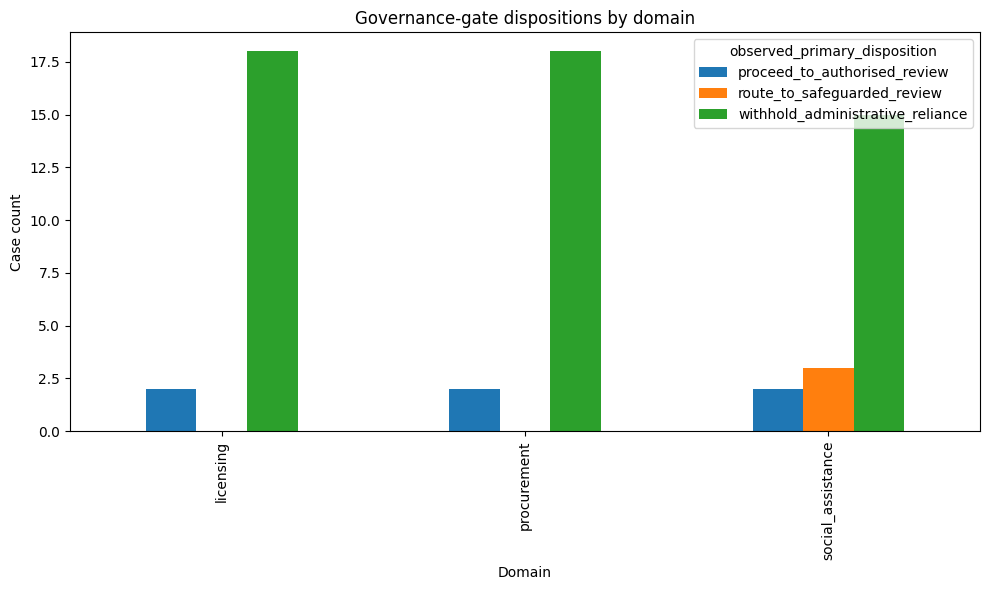

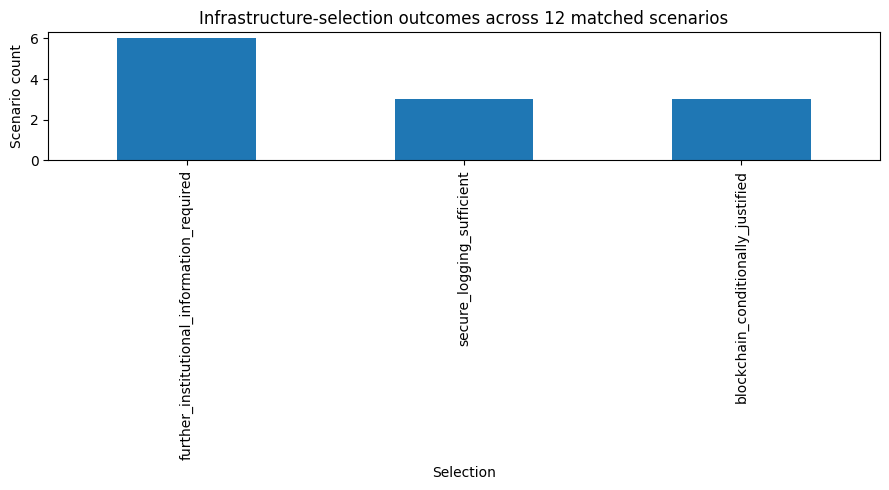

Stage disposition table


observed_primary_disposition,proceed_to_authorised_review,route_to_safeguarded_review,withhold_administrative_reliance
analytical_stage,,,
adversarial_boundary_test,0,1,17
baseline_conformance_test,6,0,15
domain_specific_protocol,0,0,3
hard_case_stress_test,0,2,16


Domain disposition table


observed_primary_disposition,proceed_to_authorised_review,route_to_safeguarded_review,withhold_administrative_reliance
domain,,,
licensing,2,0,18
procurement,2,0,18
social_assistance,2,3,15


In [27]:
# Merge stage metadata for analytical summaries.
result_analysis = GATE_CASES[["case_id", "domain", "analytical_stage", "case_category", "core_tension"]].merge(observed_gate, on="case_id")

stage_disposition = pd.crosstab(result_analysis["analytical_stage"], result_analysis["observed_primary_disposition"])
domain_disposition = pd.crosstab(result_analysis["domain"], result_analysis["observed_primary_disposition"])
infra_summary = infra_observed["observed_selection"].value_counts().rename_axis("selection").reset_index(name="count")

stage_disposition.to_csv(OUTPUT_ROOT / "summaries" / "disposition_by_analytical_stage.csv")
domain_disposition.to_csv(OUTPUT_ROOT / "summaries" / "disposition_by_domain.csv")
infra_summary.to_csv(OUTPUT_ROOT / "summaries" / "infrastructure_selection_summary.csv", index=False)

ax = domain_disposition.plot(kind="bar", figsize=(10, 6))
ax.set_title("Governance-gate dispositions by domain")
ax.set_xlabel("Domain")
ax.set_ylabel("Case count")
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "figures" / "governance_gate_dispositions_by_domain.png", dpi=200)
plt.show()

ax = infra_summary.set_index("selection")["count"].plot(kind="bar", figsize=(9, 5))
ax.set_title("Infrastructure-selection outcomes across 12 matched scenarios")
ax.set_xlabel("Selection")
ax.set_ylabel("Scenario count")
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "figures" / "infrastructure_selection_outcomes.png", dpi=200)
plt.show()

print("Stage disposition table")
display(stage_disposition)
print("Domain disposition table")
display(domain_disposition)


## 19. Claim-to-evidence and non-claim matrix

The final report states what the notebook supports and what remains outside the evidence.


In [28]:
CLAIM_TRACEABILITY = pd.DataFrame([
    {
        "claim_id": "C1",
        "supported_claim": "The governance gate produced the frozen dispositions, complete blocker sets, required actions and institutional routes across the represented 60 cases.",
        "evidence_file": "analytical_checks/governance_gate_expected_observed.csv",
        "boundary": "Internal implementation fidelity to researcher-specified conditions.",
    },
    {
        "claim_id": "C2",
        "supported_claim": "Higher GenAI confidence did not override unchanged substantive blockers in the represented pairs.",
        "evidence_file": "analytical_checks/paired_checks_observed.csv|analytical_checks/genai_role_boundary_checks.csv",
        "boundary": "No GenAI model accuracy, bias or explanation-quality test was performed.",
    },
    {
        "claim_id": "C3",
        "supported_claim": "All seven specified record-defect categories were directly represented; missing records blocked progression, while complete accountability records still did not settle substantive uncertainty in the paired cases.",
        "evidence_file": "analytical_checks/paired_checks_observed.csv|analytical_checks/accountability_record_requirement_checks.csv|summaries/targeted_record_replacement_trace.csv",
        "boundary": "No operational ledger persistence, security or audit-retrieval test was performed.",
    },
    {
        "claim_id": "C4",
        "supported_claim": "The three tensions generated domain-relevant blockers, actions and institutional routes within the represented cases.",
        "evidence_file": "summaries/tension_response_traceability.csv|analytical_checks/cross_domain_checks_observed.csv",
        "boundary": "The evaluation does not show that the tensions were resolved in real institutions.",
    },
    {
        "claim_id": "C5",
        "supported_claim": "Infrastructure selection followed institutional configuration rather than domain identity in the 12 matched scenarios.",
        "evidence_file": "analytical_checks/infrastructure_expected_observed.csv|analytical_checks/infrastructure_cross_domain_configuration_checks.csv",
        "boundary": "No deployed secure-logging or blockchain system was compared.",
    },
    {
        "claim_id": "C6",
        "supported_claim": "All nine faulty gate variants and four faulty infrastructure variants changed their frozen affected signatures.",
        "evidence_file": "faulty_variant_outputs/faulty_gate_variant_summary.csv|faulty_variant_outputs/faulty_infrastructure_variant_summary.csv",
        "boundary": "Mutation sensitivity does not establish independent validity of the substantive assumptions.",
    },
    {
        "claim_id": "C7",
        "supported_claim": "Procedural requirements associated with selected smart-government capacities are traceable to evaluated cases and checks.",
        "evidence_file": "summaries/smart_government_capacity_requirement_traceability.csv",
        "boundary": "The capacities were not measured as achieved or improved.",
    },
])

NON_CLAIMS = pd.DataFrame({
    "not_established": [
        "real_world_tension_resolution",
        "achieved_smart_government_capacities",
        "administrative_effectiveness_or_efficiency_gain",
        "legal_compliance_or_substantive_fairness",
        "generative_ai_accuracy_bias_or_explanation_quality",
        "blockchain_security_latency_cost_scalability_or_privacy_performance",
        "implementation_readiness_or_adoption_success",
        "external_validity_or_generalisation_beyond_represented_cases",
    ]
})
CLAIM_TRACEABILITY.to_csv(OUTPUT_ROOT / "summaries" / "claim_to_evidence_matrix.csv", index=False)
NON_CLAIMS.to_csv(OUTPUT_ROOT / "summaries" / "non_claims.csv", index=False)
display(CLAIM_TRACEABILITY)


,claim_id,supported_claim,evidence_file,boundary
0,C1,The governance gate produced the frozen dispos...,analytical_checks/governance_gate_expected_obs...,Internal implementation fidelity to researcher...
1,C2,Higher GenAI confidence did not override uncha...,analytical_checks/paired_checks_observed.csv|a...,"No GenAI model accuracy, bias or explanation-q..."
2,C3,All seven specified record-defect categories w...,analytical_checks/paired_checks_observed.csv|a...,"No operational ledger persistence, security or..."
3,C4,The three tensions generated domain-relevant b...,summaries/tension_response_traceability.csv|an...,The evaluation does not show that the tensions...
4,C5,Infrastructure selection followed institutiona...,analytical_checks/infrastructure_expected_obse...,No deployed secure-logging or blockchain syste...
5,C6,All nine faulty gate variants and four faulty ...,faulty_variant_outputs/faulty_gate_variant_sum...,Mutation sensitivity does not establish indepe...
6,C7,Procedural requirements associated with select...,summaries/smart_government_capacity_requiremen...,The capacities were not measured as achieved o...


## 20. Final assertions, manifests and reproducible package

The package includes frozen specifications, observed outputs, analytical checks, faulty-variant outputs, summaries, figures, environment information and file hashes.


In [29]:
# Final assertions.
assert len(GATE_CASES) == 60
assert gate_comparison["overall_match"].all()
assert paired_results["relationship_met"].all()
assert compound_results["passed"].all()
assert cross_domain_results["passed"].all()
assert GENAI_BOUNDARY_RESULTS["passed"].all()
assert infra_comparison["selection_match"].all()
assert component_observed["selection_match"].all()
assert FAULTY_GATE_SUMMARY["signature_met"].all()
assert FAULTY_INFRA_SUMMARY["signature_met"].all()

EXECUTION_FINISHED_UTC = datetime.now(timezone.utc).isoformat()

environment_lines = [
    f"python={sys.version.split()[0]}",
    f"platform={platform.platform()}",
    f"pandas={pd.__version__}",
    f"matplotlib={plt.matplotlib.__version__}",
    f"notebook_version={NOTEBOOK_VERSION}",
    f"specification_version={SPECIFICATION_VERSION}",
    f"randomness_used={str(RANDOMNESS_USED).lower()}",
]
(OUTPUT_ROOT / "logs" / "environment.txt").write_text("\n".join(environment_lines), encoding="utf-8")
(OUTPUT_ROOT / "logs" / "requirements.txt").write_text(
    f"pandas=={pd.__version__}\nmatplotlib=={plt.matplotlib.__version__}\n",
    encoding="utf-8",
)

README = """
# Pathway Governance Scenario-Based Evaluation v6.2

## Core components

- 60 governance-gate cases: 6 positive-progression, 33 single-condition, 6 compound-condition, 12 paired-adversarial and 3 domain-specific cases
- 6 paired-property checks
- 6 compound-condition fidelity checks
- 17 classified cross-domain checks
- GenAI role-boundary checks
- direct negative coverage of seven accountability-record defect categories
- targeted record-replacement traceability
- non-cosmetic logic-signature audit
- smart-government capacity-requirement traceability
- 12 matched infrastructure-selection scenarios
- 6 infrastructure component-sensitivity boundary checks
- 9 faulty governance-gate variants
- 4 faulty infrastructure-selection variants

## Claim boundary

The package supports internal procedural conformance, blocker retention, role-boundary discipline,
domain-sensitive routing, sensitivity to predefined violations and configuration-based infrastructure
selection within the represented cases. It does not establish field effectiveness, legal compliance,
achieved smart-government capacities, GenAI technical performance, blockchain technical performance,
implementation readiness or external validity.
"""
(OUTPUT_ROOT / "README.md").write_text(README.strip() + "\n", encoding="utf-8")

all_files = sorted(path for path in OUTPUT_ROOT.rglob("*") if path.is_file())
post_manifest = {
    "notebook_version": NOTEBOOK_VERSION,
    "specification_version": SPECIFICATION_VERSION,
    "execution_started_utc": EXECUTION_STARTED_UTC,
    "execution_finished_utc": EXECUTION_FINISHED_UTC,
    "randomness_used": RANDOMNESS_USED,
    "gate_case_count": len(GATE_CASES),
    "unique_gate_logic_signatures": int(scenario_audit["logic_signature"].nunique()),
    "infrastructure_scenario_count": len(INFRASTRUCTURE_SCENARIOS),
    "component_sensitivity_count": len(COMPONENT_SENSITIVITY),
    "faulty_variant_count": len(FAULTY_GATE_SUMMARY) + len(FAULTY_INFRA_SUMMARY),
    "files": {
        str(path.relative_to(OUTPUT_ROOT)): {
            "sha256": sha256_file(path),
            "bytes": path.stat().st_size,
        }
        for path in all_files
    },
}
(OUTPUT_ROOT / "provenance" / "post_execution_manifest.json").write_text(
    json.dumps(post_manifest, indent=2), encoding="utf-8"
)

zip_path = shutil.make_archive(str(OUTPUT_ROOT), "zip", root_dir=OUTPUT_ROOT)

FINAL_SUMMARY = {
    "gate_cases": len(GATE_CASES),
    "unique_input_logic_signatures": int(scenario_audit["logic_signature"].nunique()),
    "gate_dispositions": observed_gate["observed_primary_disposition"].value_counts().to_dict(),
    "paired_checks_met": int(paired_results["relationship_met"].sum()),
    "compound_checks_met": int(compound_results["passed"].sum()),
    "cross_domain_checks_met": int(cross_domain_results["passed"].sum()),
    "genai_role_boundary_checks_met": int(GENAI_BOUNDARY_RESULTS["passed"].sum()),
    "infrastructure_scenarios_matched": int(infra_comparison["selection_match"].sum()),
    "component_sensitivity_checks_met": int(component_observed["selection_match"].sum()),
    "faulty_gate_variants_matched": int(FAULTY_GATE_SUMMARY["signature_met"].sum()),
    "faulty_infrastructure_variants_matched": int(FAULTY_INFRA_SUMMARY["signature_met"].sum()),
    "randomness_used": RANDOMNESS_USED,
}
(OUTPUT_ROOT / "summaries" / "final_summary.json").write_text(
    json.dumps(FINAL_SUMMARY, indent=2), encoding="utf-8"
)

print(json.dumps(FINAL_SUMMARY, indent=2))
print(f"Output package: {OUTPUT_ROOT}")
print(f"ZIP package: {Path(zip_path).name}")


{
  "gate_cases": 60,
  "unique_input_logic_signatures": 42,
  "gate_dispositions": {
    "withhold_administrative_reliance": 51,
    "proceed_to_authorised_review": 6,
    "route_to_safeguarded_review": 3
  },
  "paired_checks_met": 6,
  "compound_checks_met": 6,
  "cross_domain_checks_met": 17,
  "genai_role_boundary_checks_met": 3,
  "infrastructure_scenarios_matched": 12,
  "component_sensitivity_checks_met": 6,
  "faulty_gate_variants_matched": 9,
  "faulty_infrastructure_variants_matched": 4,
  "randomness_used": false
}
Output package: pathway_governance_evaluation_v6_2_package
ZIP package: pathway_governance_evaluation_v6_2_package.zip


## Interpretation boundary

A successful run supports **non-trivial internal verification of specified governance logic**. It shows that the implemented gate can discriminate satisfied from unresolved conditions, retain multiple blockers, preserve authority boundaries, route domain tensions differently and apply configuration-based infrastructure selection.

The positive-progression cases include both baseline-satisfied and active-satisfied configurations, allowing the evaluation to test progression when relevant governance requirements are present and satisfied. The paired, compound, cross-domain, sensitivity and faulty-variant checks provide additional evidence on relationship preservation and rule sensitivity within the represented design.

The evaluation does not establish that the governance requirements are substantively complete, that the selected variables are the only relevant institutional variables or that the framework will produce beneficial outcomes in practice. Independent institutional cases, legal and practitioner review, bounded organisational pilots and outcome-oriented evaluation remain separate evidentiary stages.
